# Clinical Trial Landscape V2 -- Antibody Therapeutics in Oncology (Deep-Dive)
**Prepared for:** Executive / Portfolio Strategy Review
**Analyst view:** Head of Data Analytics (clinical-stage competitive intelligence)
**Source data:** `input/clinical_final_version1.csv` (/Users/revathisekar/Documents/vibe analytics trial 2/input/clinical_final_version1.csv)
**Scope:** Antibody-modality oncology clinical trials (mAb, ADC, bispecific, BiTE, CAR-T, radioligand, PROTAC),
filtered to `in_scope == True`.
**Target taxonomy:** the curated **`target_harmonized`** column only (no raw `targets_hgnc`/`target_name`).

This is the deeper, wider follow-on to `clinical_landscape_final_version1.ipynb` -- same rigor as
`ip_landscape_final_version1.ipynb`. 36 entries: landscape overview -> modality/target/tumor-type cuts
-> a true Phase-1/2/3 succeeded/failed/in-trial cross-tab (overall AND per solid tumor type) ->
population-matched "subtle divergence" analyses (same target, same tumor type: IO-combo vs
all-comers, naked mAb vs ADC, and combo-partner-class sensitivity) -> ADC payload landscape ->
termination-reason mining -> momentum (heating up / cooling down) -> Phase-1/2-only clinical
whitespace scoring (overall, by modality, by solid tumor type) -> a novel-candidate spotlight ->
portfolio shortlist -> executive summary. Every table and chart below is generated live from the
CSV via DuckDB SQL + pandas; nothing is hand-typed.

**Post-interview addendum (Entries 37-43):** built after discussing this with the executive
sponsor -- adds a Low/Medium/High risk-tier framework (validated biology / hybrid novel-modality
angle / whitespace), BOTH a tumor-agnostic and a tumor-anchored shortlist (not either/or), and a
per-candidate combo-strategy feasibility tag (monotherapy-ready vs requires IO/chemo/TKI-combo
access), closing with a consolidated recommendation matrix.

## Entry 1: Setup, Scope & Data Load

In [1]:
# Executive framing -----------------------------------------------------
# V2 goal: interrogate the antibody-oncology clinical trial landscape from
# as many independent angles as possible (modality, target, tumor type,
# phase, regimen, payload, sponsor, time) to inform where WE should place
# our own antibody-therapeutics program bet. Source:
# input/clinical_final_version1.csv. Target taxonomy: target_harmonized ONLY.
con = duckdb.connect()
con.execute(f"CREATE OR REPLACE VIEW raw_trials AS SELECT * FROM read_csv_auto('{INPUT_CSV}', ALL_VARCHAR=FALSE, SAMPLE_SIZE=-1)")
raw = con.sql("SELECT * FROM raw_trials").df()
print(f"Raw rows: {len(raw):,}   Columns: {raw.shape[1]}   Unique NCTs: {raw['nct'].nunique():,}")
print()
print(con.sql('''
    SELECT in_scope, COUNT(*) AS n_rows
    FROM raw_trials GROUP BY 1 ORDER BY 2 DESC
''').df().to_string(index=False))

Raw rows: 19,357   Columns: 63   Unique NCTs: 18,383

 in_scope  n_rows
     True   16648
    False    2684
     <NA>      25


## Entry 2: Analytic Base Table -- Scope Filter, Canonical Phase, Outcome & Termination-Reason Buckets

In [2]:
# Keep in-scope antibody-modality oncology trials only. Build:
#  - phase_canon: fine-grained canonical phase text
#  - phase_group: SIMPLE 1/2/3/4 division by FURTHEST phase attained
#    (a "Phase 1/2" trial is counted under Phase 2, its furthest stage --
#    this is the "phase division (phase1-2-3)" grouping used throughout).
#  - outcome_bucket: 4-way Success / Failure / Ongoing-Pending / Unclear
#  - stop_reason_bucket: why a terminated trial stopped (accrual, safety,
#    efficacy/futility, business/funding, regulatory, covid, other) mined
#    from the free-text ctgov_why_stopped field.
df = raw[raw["in_scope"] == True].copy()  # noqa: E712 (nullable BooleanArray from DuckDB)

def phase_group(raw_phase, ctgov_phase):
    s = str(ctgov_phase) if pd.notna(ctgov_phase) and str(ctgov_phase) != "None" else str(raw_phase)
    s = s.upper()
    has1 = ("PHASE1" in s) or ("EARLY_PHASE1" in s)
    has2 = "PHASE2" in s
    has3 = "PHASE3" in s
    has4 = "PHASE4" in s
    if has4:
        return "Phase 4"
    if has3:
        return "Phase 3"
    if has2:
        return "Phase 2"
    if has1:
        return "Phase 1"
    return "Unknown"

def canon_phase(raw_phase, ctgov_phase):
    s = str(ctgov_phase) if pd.notna(ctgov_phase) and str(ctgov_phase) != "None" else str(raw_phase)
    s = s.upper()
    has1 = ("PHASE1" in s) or ("EARLY_PHASE1" in s)
    has2 = "PHASE2" in s
    has3 = "PHASE3" in s
    has4 = "PHASE4" in s
    if has4:
        return "Phase 4"
    if has3 and has2:
        return "Phase 2/3"
    if has3:
        return "Phase 3"
    if has2 and has1:
        return "Phase 1/2"
    if has2:
        return "Phase 2"
    if has1:
        return "Phase 1"
    return "Unknown"

df["phase_canon"] = [canon_phase(p, c) for p, c in zip(df["phase"], df["ctgov_phase"])]
df["phase_group"] = [phase_group(p, c) for p, c in zip(df["phase"], df["ctgov_phase"])]

OUTCOME_BUCKET = {
    "positive": "Success", "approved": "Success",
    "negative": "Failure", "terminated": "Failure",
    "ongoing": "Ongoing/Pending", "pending": "Ongoing/Pending",
    "unclear": "Unclear",
}
df["outcome_bucket"] = df["outcome"].map(OUTCOME_BUCKET).fillna("Unclear")

df["start_year"] = pd.to_datetime(df["start_date"], errors="coerce", format="mixed").dt.year
df["target_h"] = df["target_harmonized"].replace({"": np.nan})
df["n_targets_h"] = pd.to_numeric(df["n_targets_harmonized"], errors="coerce")

STOP_REASON_CATS = [
    ("Accrual/Enrollment", r"accrual|enroll|recruit"),
    ("Business/Funding/Strategic", r"business|funding|\bfund\b|strategic|pipeline priorit|portfolio|sponsor decision|company decision"),
    ("Safety/Toxicity", r"safety|toxicit|adverse|\brisk\b|dsmb|\bdlt\b"),
    ("Efficacy/Futility", r"efficacy|futility|interim analysis|did not meet|failed to meet|lack of benefit"),
    ("COVID/Logistics", r"covid|pandemic|logistic"),
    ("Regulatory/Administrative", r"regulatory|protocol amendment|administrative|closed by sponsor|study design"),
]
STOP_COMPILED = [(n, re.compile(p, re.IGNORECASE)) for n, p in STOP_REASON_CATS]

def stop_bucket(text):
    if pd.isna(text):
        return None
    t = str(text)
    for name, rx in STOP_COMPILED:
        if rx.search(t):
            return name
    return "Other/Unspecified"

df["stop_reason_bucket"] = df["ctgov_why_stopped"].apply(stop_bucket)

con.register("trials", df)
print(f"In-scope analytic base: {len(df):,} rows ({df['nct'].nunique():,} unique NCTs)")
print()
print("Furthest-phase group coverage (Phase 1/2/3/4/Unknown):")
print(df["phase_group"].value_counts(dropna=False).to_string())
print()
print("Outcome bucket coverage:")
print(df["outcome_bucket"].value_counts(dropna=False).to_string())
print()
print(f"Terminated trials with a mined stop-reason bucket: {df['stop_reason_bucket'].notna().sum():,} "
      f"of {(df['outcome']=='terminated').sum():,} terminated rows.")

In-scope analytic base: 16,648 rows (15,851 unique NCTs)

Furthest-phase group coverage (Phase 1/2/3/4/Unknown):
phase_group
Phase 2    9174
Phase 1    4015
Phase 3    1763
Unknown    1561
Phase 4     135

Outcome bucket coverage:
outcome_bucket
Ongoing/Pending    10192
Failure             2678
Unclear             2463
Success             1315

Terminated trials with a mined stop-reason bucket: 2,228 of 2,229 terminated rows.


## Entry 3: Tumor-Type Harmonization Engine (Solid Tumor Classifier)

In [3]:
# There is no curated tumor-type column, so we build one from
# ctgov_conditions (fallback m_conditions) using an ordered keyword/regex
# classifier -- most-specific categories checked first. A trial can carry
# MULTIPLE tags (basket trials); we keep the full tag list for
# tumor-specific ("population-matched") cuts and a single `tumor_primary`
# (first match) for row-level summaries.
TUMOR_CATEGORIES = [
    ("NSCLC", r"non[- ]?small[- ]?cell lung|nsclc"),
    ("SCLC", r"small[- ]?cell lung (carcinoma|cancer)|\bsclc\b"),
    ("Lung_Other", r"\blung\b|pulmonary"),
    ("Breast", r"\bbreast\b"),
    ("Ovarian", r"ovarian|\bovary\b"),
    ("Endometrial_Uterine", r"endometrial|\buterine\b"),
    ("Cervical", r"cervical|\bcervix\b"),
    ("Colorectal", r"colorectal|\bcolon\b|\brectal\b|\brectum\b"),
    ("Gastric_Esophageal", r"gastric|\bstomach\b|esophageal|oesophageal|gastroesophageal|\bgej\b"),
    ("Hepatocellular", r"hepatocellular|\bhcc\b"),
    ("Biliary_Cholangio", r"cholangiocarcinoma|\bbiliary\b"),
    ("Pancreatic", r"pancreatic|\bpancreas\b"),
    ("RCC", r"renal cell|\brcc\b|kidney cancer"),
    ("Bladder_Urothelial", r"\bbladder\b|urothelial"),
    ("Prostate", r"prostat"),
    ("Melanoma", r"melanoma"),
    ("HNSCC", r"head and neck|nasopharyngeal|oropharyngeal|laryngeal|hypopharyngeal|oral cavity"),
    ("Glioma_CNS", r"glioma|glioblastoma|astrocytoma|central nervous system|\bcns\b|brain (tumou?r|neoplasm)"),
    ("Mesothelioma", r"mesothelioma"),
    ("Sarcoma", r"sarcoma"),
    ("Thyroid", r"thyroid"),
    ("Skin_NonMelanoma", r"squamous cell carcinoma of the skin|cutaneous squamous|basal cell carcinoma|merkel cell"),
    ("Neuroendocrine", r"neuroendocrine|carcinoid"),
    ("GermCell_Testicular", r"testicular|germ cell"),
    ("Adrenal", r"adrenocortical|adrenal"),
    ("Salivary_Gland", r"salivary gland"),
    ("Solid_Tumor_Basket", r"solid tumou?r|advanced cancer|advanced malignant neoplasm|\bany cancer\b|metastatic cancer|metastatic solid"),
    ("Hematologic_Lymphoma", r"lymphoma"),
    ("Hematologic_Leukemia", r"leuk[ae]mia"),
    ("Hematologic_Myeloma", r"myeloma"),
    ("Hematologic_MDS_MPN", r"myelodysplastic|myeloproliferative"),
]
COMPILED = [(name, re.compile(pat, re.IGNORECASE)) for name, pat in TUMOR_CATEGORIES]

def classify_tumor_tags(cond_text):
    if not cond_text or pd.isna(cond_text):
        return []
    return [name for name, rx in COMPILED if rx.search(str(cond_text))]

df["condition_text"] = df["ctgov_conditions"].fillna(df["m_conditions"])
df["tumor_tags"] = df["condition_text"].apply(classify_tumor_tags)
df["tumor_primary"] = df["tumor_tags"].apply(lambda t: t[0] if t else None)
df["tumor_primary"] = df["tumor_primary"].where(
    df["tumor_primary"].notna(),
    np.where(df["condition_text"].notna(), "Other_Unclassified", "No_Condition_Data"),
)

def tumor_group(primary):
    if primary.startswith("Hematologic"):
        return "Hematologic"
    if primary == "Solid_Tumor_Basket":
        return "Solid (Basket/Unspecified)"
    if primary in ("Other_Unclassified", "No_Condition_Data"):
        return "Unclassified"
    return "Solid (Named Type)"

df["tumor_group"] = df["tumor_primary"].apply(tumor_group)
con.register("trials", df)

print("Tumor-group coverage (row-level, primary tag):")
print(df["tumor_group"].value_counts(dropna=False).to_string())
print()
print(f"Classifier hit-rate (rows w/ condition text that matched >=1 tag): "
      f"{(df['tumor_tags'].str.len() > 0).sum():,} / {df['condition_text'].notna().sum():,}")

top_primary = df["tumor_primary"].value_counts().head(25).to_frame("n_trials")
display(top_primary, name="entry03_top_tumor_primary")

tumor_junction = df[["nct", "target_h", "modality_code", "phase_canon", "phase_group",
                     "outcome_bucket", "is_combo", "combo_partner_class", "tumor_tags"]].explode("tumor_tags")
tumor_junction = tumor_junction.rename(columns={"tumor_tags": "tumor_type"})
tumor_junction = tumor_junction[tumor_junction["tumor_type"].notna()]
con.register("tumor_junction", tumor_junction)
print(f"\nTumor-tag junction rows (trial x tumor tag): {len(tumor_junction):,}")

Tumor-group coverage (row-level, primary tag):
tumor_group
Solid (Named Type)            10956
Hematologic                    3253
Unclassified                   1425
Solid (Basket/Unspecified)     1014

Classifier hit-rate (rows w/ condition text that matched >=1 tag): 15,223 / 16,574

Tumor-tag junction rows (trial x tumor tag): 24,823


,n_trials
tumor_primary,
NSCLC,2355
Hematologic_Lymphoma,1939
Breast,1820
Other_Unclassified,1351
Colorectal,1101
Solid_Tumor_Basket,1014
Gastric_Esophageal,761
Hematologic_Leukemia,745
Lung_Other,632


## Entry 4: Modality Landscape Overview & Filing/Start Trend

,modality_code,n_trials,n_sponsors,n_distinct_targets
0,MAB,12446,2486,908
1,ADC,1550,472,395
2,CAR-T,1464,420,221
3,BISPECIFIC,1060,403,273
4,BiTE,63,46,26
5,OUT_OF_SCOPE,38,29,19
6,RADIOLIGAND,12,11,7
7,PROTAC,11,7,5
8,MULTISPECIFIC,3,3,3
9,ANTISENSE,1,1,1


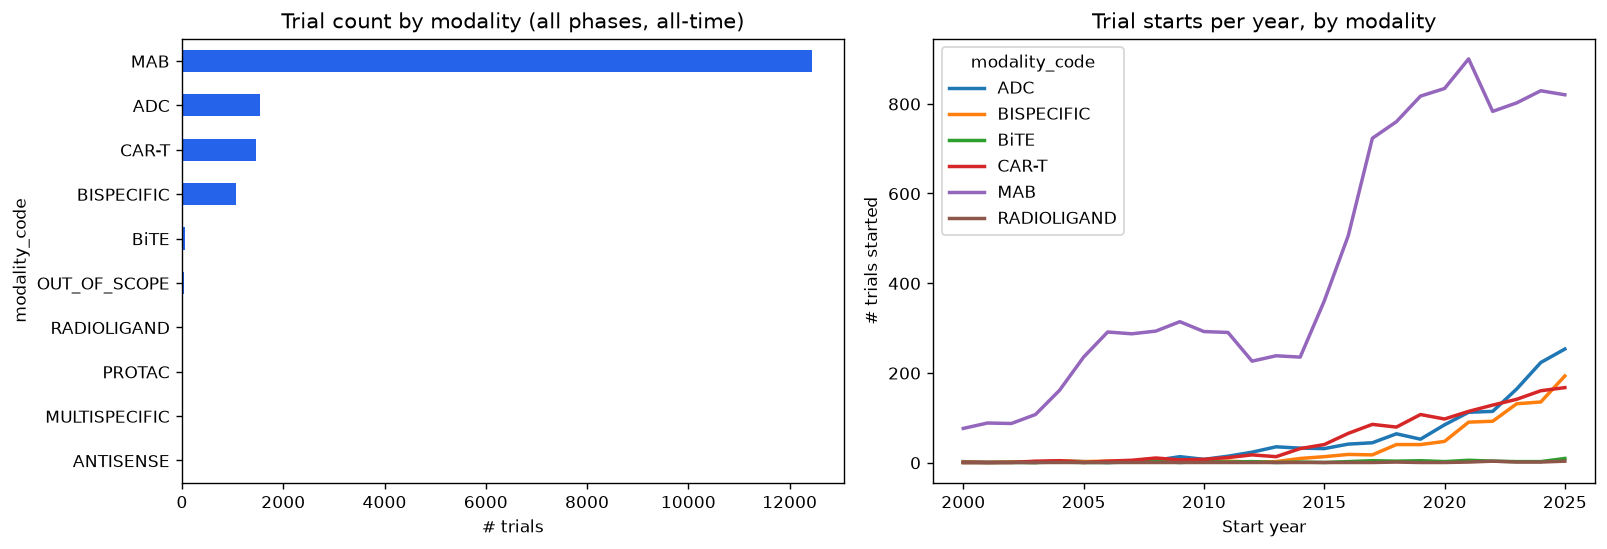

In [4]:
q = con.sql('''
    SELECT modality_code, COUNT(*) AS n_trials,
           COUNT(DISTINCT lead_sponsor_golden) AS n_sponsors,
           COUNT(DISTINCT target_h) AS n_distinct_targets
    FROM trials GROUP BY 1 ORDER BY n_trials DESC
''').df()
display(q, name="entry04_modality_overview")

trend = con.sql('''
    SELECT start_year, modality_code, COUNT(*) AS n_trials
    FROM trials
    WHERE start_year BETWEEN 2000 AND 2025
      AND modality_code IN ('MAB','ADC','BISPECIFIC','CAR-T','BiTE','RADIOLIGAND')
    GROUP BY 1,2
''').df()
pivot = trend.pivot_table(index="start_year", columns="modality_code", values="n_trials", fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
q.set_index("modality_code")["n_trials"].sort_values().plot(kind="barh", ax=axes[0], color="#2563eb")
axes[0].set_title("Trial count by modality (all phases, all-time)")
axes[0].set_xlabel("# trials")

pivot.plot(ax=axes[1], linewidth=2)
axes[1].set_title("Trial starts per year, by modality")
axes[1].set_xlabel("Start year"); axes[1].set_ylabel("# trials started")
plt.tight_layout()

## Entry 5: Target Landscape Overview (Top 30 Targets by Clinical Activity, target_harmonized)

In [5]:
q = con.sql('''
    SELECT target_h AS target_harmonized, COUNT(*) AS n_trials,
           COUNT(DISTINCT lead_sponsor_golden) AS n_sponsors,
           COUNT(DISTINCT modality_code) AS n_modalities,
           COUNT(DISTINCT nct) AS n_ncts
    FROM trials
    WHERE target_h IS NOT NULL
    GROUP BY 1 ORDER BY n_trials DESC LIMIT 30
''').df()
display(q, name="entry05_top30_targets")
print(f"Distinct target_harmonized values (incl. multi-target combos): {df['target_h'].nunique():,}")

Distinct target_harmonized values (incl. multi-target combos): 1,572


,target_harmonized,n_trials,n_sponsors,n_modalities,n_ncts
0,PD-1,2908,978,6,2829
1,HER2,1171,430,5,1158
2,VEGF,863,345,4,811
3,PD-L1,791,349,5,776
4,CD20,788,307,3,788
5,EGFR,738,339,6,701
6,PD-1|PD-L1,471,266,5,470
7,CD19,432,209,5,432
8,CTLA-4|PD-1,351,184,3,350
9,CD38,165,97,3,165


## Entry 6: Modality x Phase Funnel (Development-Stage Mix)

phase_group,Phase 1,Phase 2,Phase 3,Phase 4,Unknown
modality_code,,,,,
ADC,348.0,836.0,200.0,21.0,145.0
BISPECIFIC,309.0,561.0,78.0,6.0,106.0
BiTE,25.0,25.0,3.0,1.0,9.0
CAR-T,844.0,492.0,12.0,1.0,115.0
MAB,2475.0,7220.0,1470.0,106.0,1175.0
RADIOLIGAND,4.0,8.0,0.0,0.0,0.0


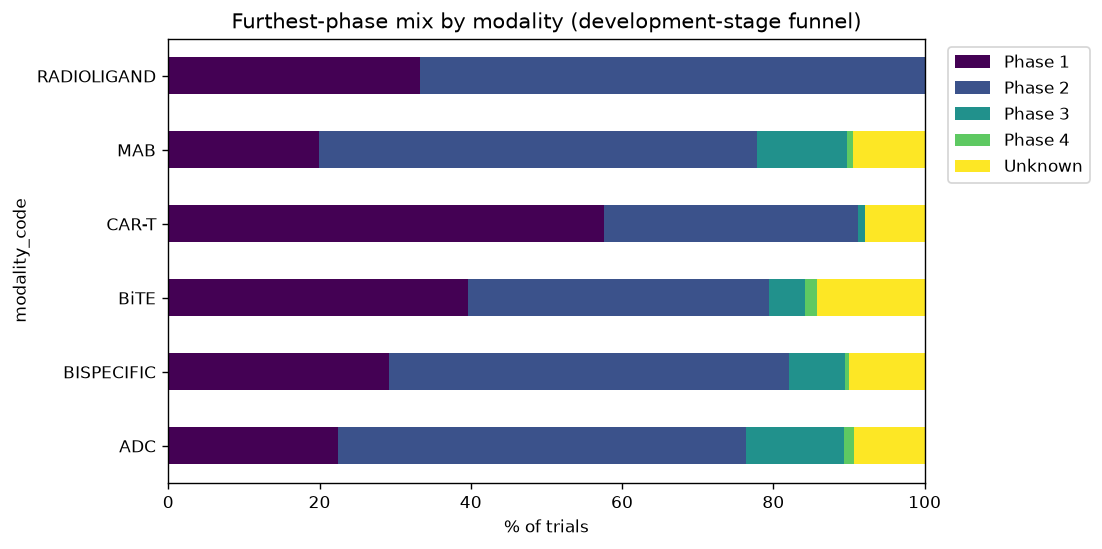

In [6]:
q = con.sql('''
    SELECT modality_code, phase_group, COUNT(*) AS n
    FROM trials WHERE modality_code IN ('MAB','ADC','BISPECIFIC','CAR-T','BiTE','RADIOLIGAND')
    GROUP BY 1,2
''').df()
pivot = q.pivot_table(index="modality_code", columns="phase_group", values="n", fill_value=0)
order = ["Phase 1", "Phase 2", "Phase 3", "Phase 4", "Unknown"]
pivot = pivot[[c for c in order if c in pivot.columns]]
display(pivot, name="entry06_modality_phase_counts")

pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
fig, ax = plt.subplots(figsize=(9, 4.5))
pivot_pct.plot(kind="barh", stacked=True, ax=ax, colormap="viridis")
ax.set_xlabel("% of trials"); ax.set_title("Furthest-phase mix by modality (development-stage funnel)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

## Entry 7: Target x Phase Matrix (Top 25 Targets)

phase_group,Phase 1,Phase 2,Phase 3,Phase 4,Unknown
target_h,,,,,
PD-1,531,1736,315,23,303
HER2,151,588,191,24,217
VEGF,132,522,112,15,82
PD-L1,167,467,103,4,50
CD20,119,490,106,12,61
EGFR,141,447,79,6,65
PD-1|PD-L1,75,284,67,2,43
CD19,220,155,9,0,48
CTLA-4|PD-1,71,230,29,0,21


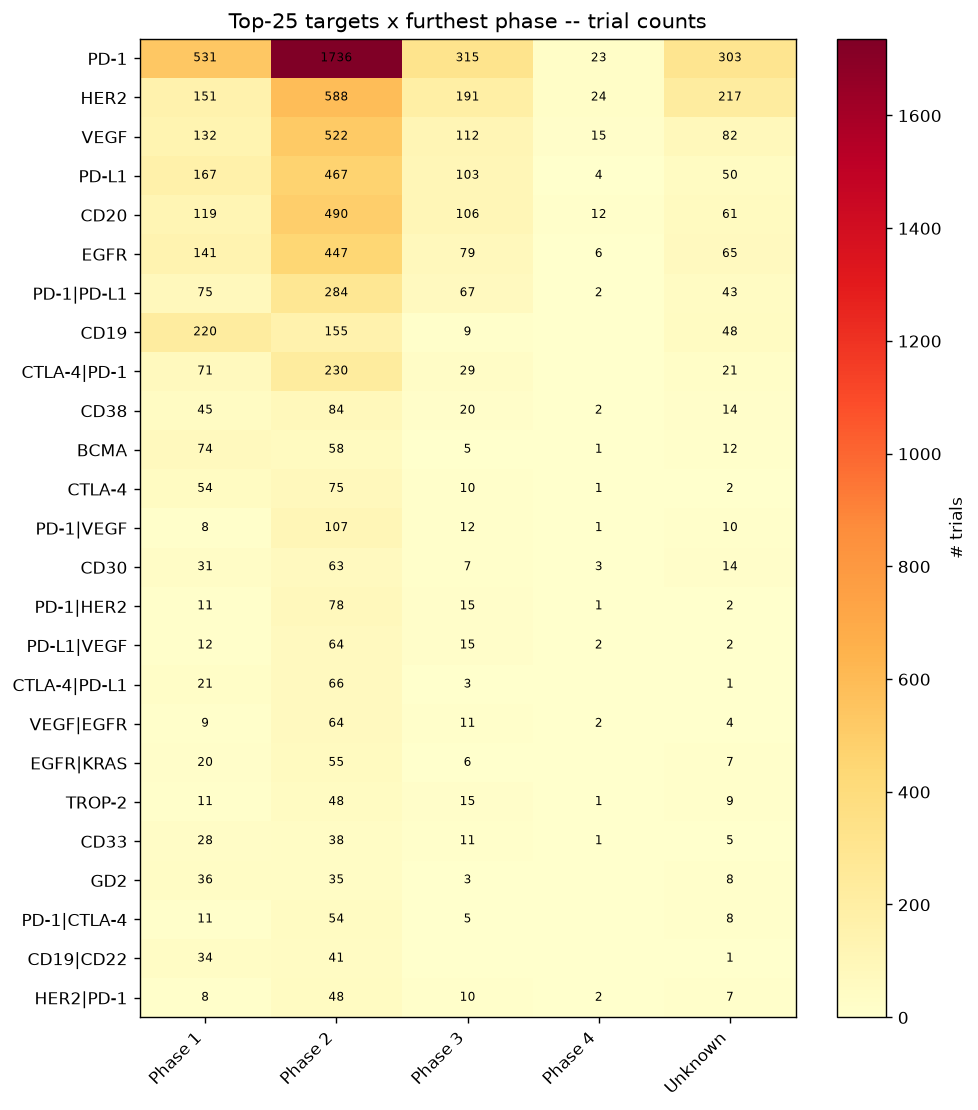

In [7]:
top25 = con.sql("SELECT target_h FROM trials WHERE target_h IS NOT NULL GROUP BY 1 ORDER BY COUNT(*) DESC LIMIT 25").df()["target_h"].tolist()
mat = df[df["target_h"].isin(top25)].pivot_table(index="target_h", columns="phase_group", values="nct", aggfunc="count", fill_value=0)
mat = mat.reindex(top25)
order = ["Phase 1", "Phase 2", "Phase 3", "Phase 4", "Unknown"]
mat = mat[[c for c in order if c in mat.columns]]
display(mat, name="entry07_top25_target_phase_matrix")

fig, ax = plt.subplots(figsize=(8, 9))
im = ax.imshow(mat.values, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(len(mat.columns))); ax.set_xticklabels(mat.columns, rotation=45, ha="right")
ax.set_yticks(range(len(mat.index))); ax.set_yticklabels(mat.index)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        v = mat.values[i, j]
        if v > 0:
            ax.text(j, i, int(v), ha="center", va="center", fontsize=7)
ax.set_title("Top-25 targets x furthest phase -- trial counts")
plt.colorbar(im, ax=ax, label="# trials")
plt.tight_layout()

## Entry 8: Modality-Level Clinical Outcome Rates

outcome_bucket,Failure,Ongoing/Pending,Success,Unclear
modality_code,,,,
ADC,234.0,1074.0,146.0,96.0
BISPECIFIC,121.0,721.0,101.0,117.0
BiTE,17.0,37.0,2.0,7.0
CAR-T,160.0,890.0,19.0,395.0
MAB,2134.0,7426.0,1046.0,1840.0
RADIOLIGAND,3.0,8.0,0.0,1.0


outcome_bucket,Failure,Ongoing/Pending,Success,Unclear
modality_code,,,,
ADC,15.1,69.3,9.4,6.2
BISPECIFIC,11.4,68.0,9.5,11.0
BiTE,27.0,58.7,3.2,11.1
CAR-T,10.9,60.8,1.3,27.0
MAB,17.1,59.7,8.4,14.8
RADIOLIGAND,25.0,66.7,0.0,8.3


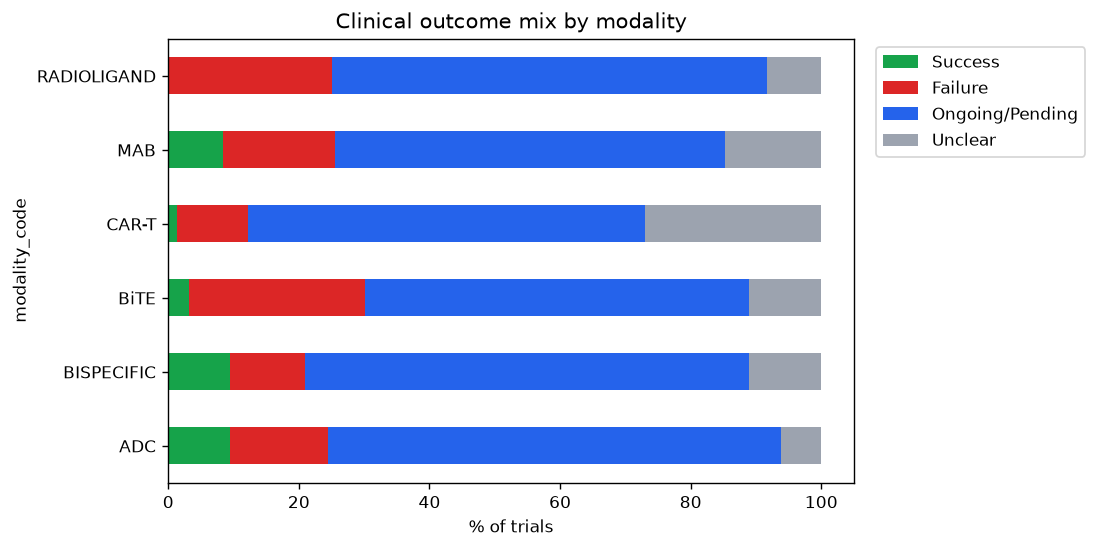

In [8]:
q = con.sql('''
    SELECT modality_code, outcome_bucket, COUNT(*) AS n
    FROM trials WHERE modality_code IN ('MAB','ADC','BISPECIFIC','CAR-T','BiTE','RADIOLIGAND')
    GROUP BY 1,2
''').df()
pivot = q.pivot_table(index="modality_code", columns="outcome_bucket", values="n", fill_value=0)
pivot_pct = (pivot.div(pivot.sum(axis=1), axis=0) * 100).round(1)
display(pivot, name="entry08_modality_outcome_counts")
display(pivot_pct, name="entry08_modality_outcome_pct")

cols = [c for c in ["Success", "Failure", "Ongoing/Pending", "Unclear"] if c in pivot_pct.columns]
fig, ax = plt.subplots(figsize=(9, 4.5))
pivot_pct[cols].plot(kind="barh", stacked=True, ax=ax, color=["#16a34a", "#dc2626", "#2563eb", "#9ca3af"])
ax.set_xlabel("% of trials"); ax.set_title("Clinical outcome mix by modality")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

## Entry 9: Target x Phase-Division (1/2/3) Outcome Cross-Tab -- Succeeded / Failed / In-Trial BY PHASE

In [9]:
# This is the core "phase division (phase1-2-3)" ask: for every target,
# how many trials succeeded / failed / are still ongoing WITHIN Phase 1,
# WITHIN Phase 2, and WITHIN Phase 3 specifically (furthest-phase group).
q = con.sql('''
    SELECT target_h AS target_harmonized, phase_group, outcome_bucket, COUNT(*) AS n
    FROM trials
    WHERE target_h IS NOT NULL AND phase_group IN ('Phase 1','Phase 2','Phase 3')
    GROUP BY 1,2,3
''').df()
wide = q.pivot_table(index="target_harmonized", columns=["phase_group", "outcome_bucket"], values="n", fill_value=0)
wide.columns = [f"{p.replace('Phase ', 'Ph')}_{o.replace('/', '_')}" for p, o in wide.columns]
for p in ("Ph1", "Ph2", "Ph3"):
    cols = [c for c in wide.columns if c.startswith(p + "_")]
    wide[f"{p}_total"] = wide[cols].sum(axis=1) if cols else 0
wide["grand_total"] = wide[[c for c in wide.columns if c.endswith("_total")]].sum(axis=1)
wide = wide[wide["grand_total"] >= 5].sort_values("grand_total", ascending=False)

def phase_status(row, p):
    succ = row.get(f"{p}_Success", 0)
    fail = row.get(f"{p}_Failure", 0)
    ong = row.get(f"{p}_Ongoing_Pending", 0)
    if succ > 0 and fail > 0:
        return "Mixed"
    if succ > 0:
        return "Succeeded"
    if fail > 0:
        return "Failed"
    if ong > 0:
        return "In-trial"
    return "-"

for p in ("Ph1", "Ph2", "Ph3"):
    wide[f"{p}_status"] = wide.apply(lambda r: phase_status(r, p), axis=1)

TARGET_PHASE_XTAB = wide
display_cols = [c for c in wide.columns if c != "grand_total"]
display(wide[display_cols], name="entry09_target_phase_outcome_xtab")

print("Phase-by-phase status summary across all qualifying targets (>=5 trials total):")
for p, label in [("Ph1", "Phase 1"), ("Ph2", "Phase 2"), ("Ph3", "Phase 3")]:
    print(f"\n{label}:")
    print(wide[f"{p}_status"].value_counts().to_string())

Phase-by-phase status summary across all qualifying targets (>=5 trials total):

Phase 1:
Ph1_status
Failed       72
In-trial     68
-            36
Mixed        33
Succeeded    20

Phase 2:
Ph2_status
Failed       78
Mixed        71
In-trial     54
Succeeded    19
-             7

Phase 3:
Ph3_status
-            77
In-trial     69
Failed       45
Succeeded    21
Mixed        17


,Ph1_Failure,Ph1_Ongoing_Pending,Ph1_Success,Ph1_Unclear,Ph2_Failure,Ph2_Ongoing_Pending,Ph2_Success,Ph2_Unclear,Ph3_Failure,Ph3_Ongoing_Pending,Ph3_Success,Ph3_Unclear,Ph1_total,Ph2_total,Ph3_total,Ph1_status,Ph2_status,Ph3_status
target_harmonized,,,,,,,,,,,,,,,,,,
PD-1,100.0,291.0,77.0,63.0,221.0,975.0,200.0,340.0,35.0,200.0,53.0,27.0,531.0,1736.0,315.0,Mixed,Mixed,Mixed
HER2,32.0,100.0,15.0,4.0,101.0,388.0,29.0,70.0,12.0,142.0,19.0,18.0,151.0,588.0,191.0,Mixed,Mixed,Mixed
VEGF,15.0,83.0,24.0,10.0,87.0,245.0,144.0,46.0,14.0,48.0,40.0,10.0,132.0,522.0,112.0,Mixed,Mixed,Mixed
PD-L1,44.0,94.0,14.0,15.0,77.0,285.0,52.0,53.0,12.0,75.0,14.0,2.0,167.0,467.0,103.0,Mixed,Mixed,Mixed
CD20,29.0,76.0,7.0,7.0,102.0,331.0,21.0,36.0,21.0,70.0,5.0,10.0,119.0,490.0,106.0,Mixed,Mixed,Mixed
EGFR,42.0,75.0,5.0,19.0,138.0,240.0,6.0,63.0,16.0,46.0,4.0,13.0,141.0,447.0,79.0,Mixed,Mixed,Mixed
PD-1|PD-L1,15.0,46.0,2.0,12.0,47.0,158.0,14.0,65.0,8.0,46.0,5.0,8.0,75.0,284.0,67.0,Mixed,Mixed,Mixed
CD19,17.0,130.0,3.0,70.0,17.0,89.0,6.0,43.0,2.0,3.0,1.0,3.0,220.0,155.0,9.0,Mixed,Mixed,Mixed
CTLA-4|PD-1,14.0,48.0,5.0,4.0,38.0,162.0,11.0,19.0,1.0,27.0,0.0,1.0,71.0,230.0,29.0,Mixed,Mixed,Failed


## Entry 10: Chart -- Target Success/Failure Counts, Split by Phase 1 / Phase 2 / Phase 3

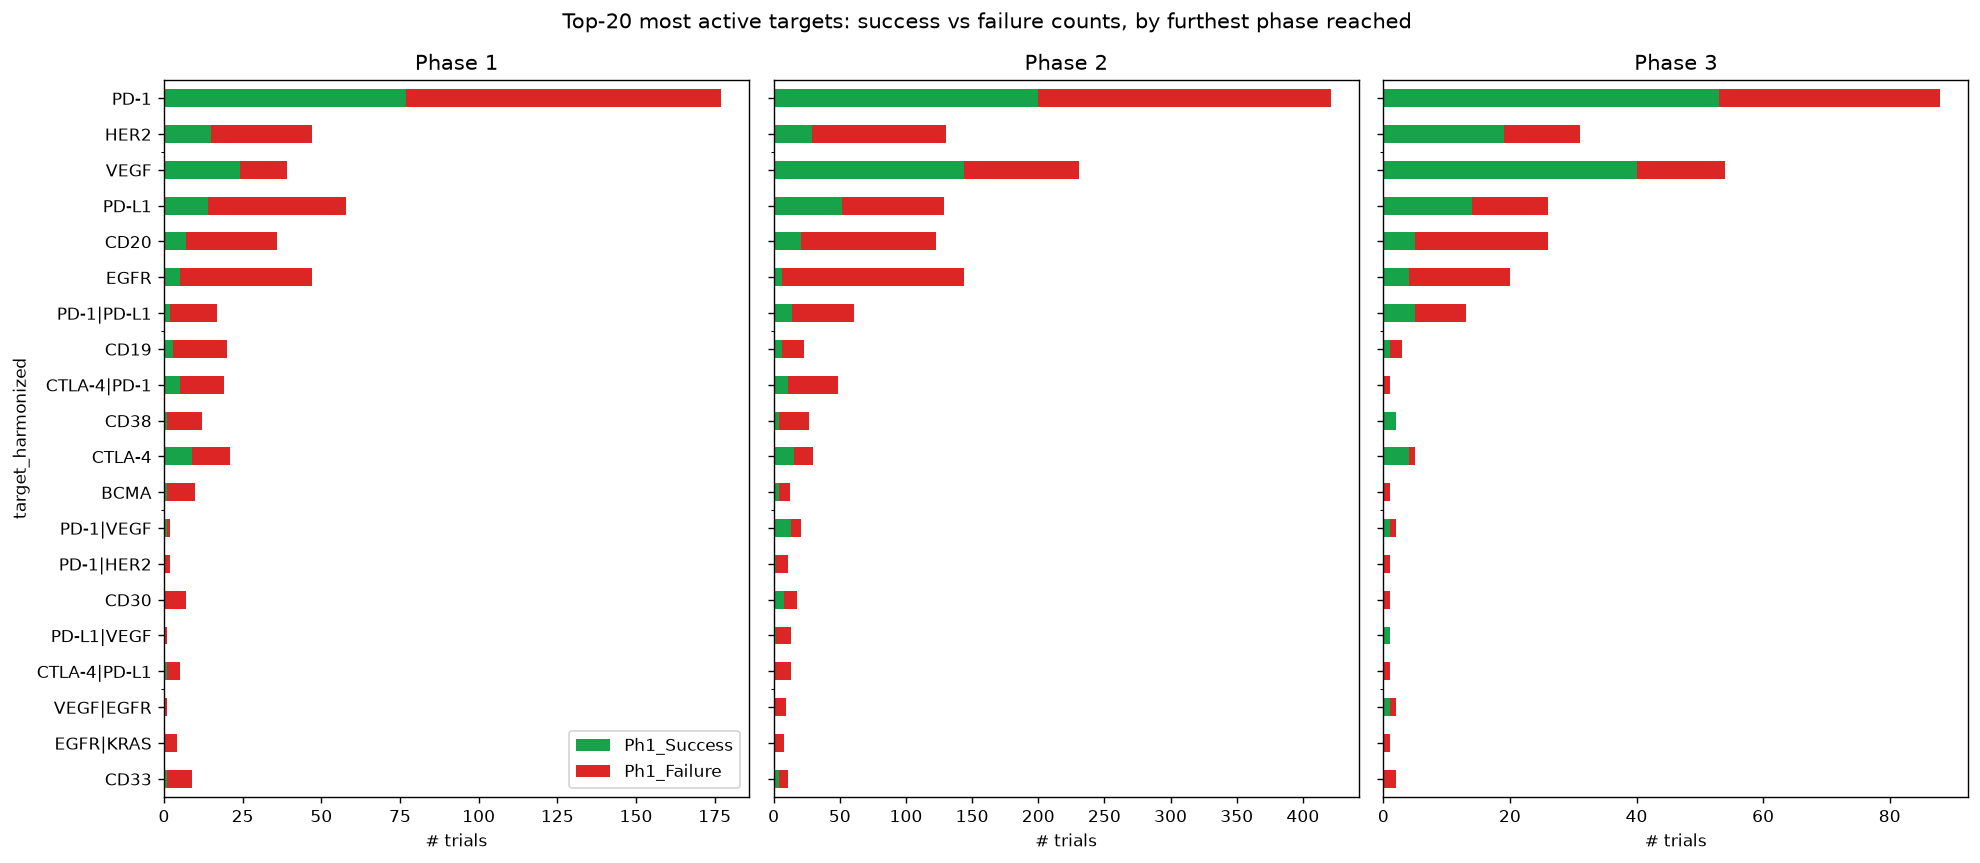

In [10]:
top20 = TARGET_PHASE_XTAB.sort_values("grand_total", ascending=False).head(20)
fig, axes = plt.subplots(1, 3, figsize=(16, 7), sharey=True)
for ax, p, label in zip(axes, ("Ph1", "Ph2", "Ph3"), ("Phase 1", "Phase 2", "Phase 3")):
    succ_col, fail_col = f"{p}_Success", f"{p}_Failure"
    sub = top20[[succ_col, fail_col]].iloc[::-1] if succ_col in top20.columns and fail_col in top20.columns else pd.DataFrame(index=top20.index[::-1])
    if not sub.empty:
        sub.plot(kind="barh", stacked=True, ax=ax, color=["#16a34a", "#dc2626"], legend=(ax is axes[0]))
    ax.set_title(label)
    ax.set_xlabel("# trials")
plt.suptitle("Top-20 most active targets: success vs failure counts, by furthest phase reached")
plt.tight_layout()

## Entry 11: Target Validation Scorecard -- Overall Succeeded / Failed / Still-in-Trial Status

In [11]:
q = con.sql('''
    SELECT target_h AS target_harmonized,
           COUNT(*) AS n_trials,
           COUNT(DISTINCT lead_sponsor_golden) AS n_sponsors,
           SUM(CASE WHEN outcome_bucket='Success' THEN 1 ELSE 0 END) AS n_success,
           SUM(CASE WHEN outcome_bucket='Failure' THEN 1 ELSE 0 END) AS n_failure,
           SUM(CASE WHEN outcome_bucket='Ongoing/Pending' THEN 1 ELSE 0 END) AS n_ongoing,
           SUM(CASE WHEN outcome_bucket='Unclear' THEN 1 ELSE 0 END) AS n_unclear,
           SUM(CASE WHEN outcome='approved' THEN 1 ELSE 0 END) AS n_approved,
           MAX(start_year) AS latest_start_year
    FROM trials
    WHERE target_h IS NOT NULL
    GROUP BY 1
    HAVING COUNT(*) >= 5
    ORDER BY n_trials DESC
''').df()
q["success_rate_%"] = (q["n_success"] / q["n_trials"] * 100).round(1)
q["failure_rate_%"] = (q["n_failure"] / q["n_trials"] * 100).round(1)

def target_status(row):
    if row["n_success"] > 0 and row["n_failure"] > 0:
        return "Mixed (succeeded & failed)"
    if row["n_success"] > 0:
        return "Validated (success recorded)"
    if row["n_failure"] > 0:
        return "Failed only (no success yet)"
    return "Still-in-trial (no readout yet)"

q["target_status"] = q.apply(target_status, axis=1)
TARGET_SCORECARD = q
display(q, name="entry11_target_outcome_scorecard")
print(f"\n{len(q)} targets have >=5 trials. Status breakdown:")
display(q["target_status"].value_counts().to_frame("n_targets"), name="entry11_target_status_summary")


243 targets have >=5 trials. Status breakdown:


,target_harmonized,n_trials,n_sponsors,n_success,n_failure,n_ongoing,n_unclear,n_approved,latest_start_year,success_rate_%,failure_rate_%,target_status
0,PD-1,2908,978,350.0,365.0,1562.0,631.0,274.0,2027.0,12.0,12.6,Mixed (succeeded & failed)
1,HER2,1171,430,69.0,156.0,774.0,172.0,3.0,2027.0,5.9,13.3,Mixed (succeeded & failed)
2,VEGF,863,345,224.0,125.0,423.0,91.0,201.0,2026.0,26.0,14.5,Mixed (succeeded & failed)
3,PD-L1,791,349,81.0,138.0,479.0,93.0,64.0,2027.0,10.2,17.4,Mixed (succeeded & failed)
4,CD20,788,307,33.0,156.0,521.0,78.0,0.0,2026.0,4.2,19.8,Mixed (succeeded & failed)
5,EGFR,738,339,16.0,202.0,390.0,130.0,6.0,2027.0,2.2,27.4,Mixed (succeeded & failed)
6,PD-1|PD-L1,471,266,22.0,70.0,271.0,108.0,1.0,2026.0,4.7,14.9,Mixed (succeeded & failed)
7,CD19,432,209,11.0,37.0,252.0,132.0,1.0,2026.0,2.5,8.6,Mixed (succeeded & failed)
8,CTLA-4|PD-1,351,184,16.0,54.0,248.0,33.0,0.0,2026.0,4.6,15.4,Mixed (succeeded & failed)
9,CD38,165,97,7.0,34.0,106.0,18.0,0.0,2027.0,4.2,20.6,Mixed (succeeded & failed)


,n_targets
target_status,
Mixed (succeeded & failed),99
Failed only (no success yet),83
Still-in-trial (no readout yet),40
Validated (success recorded),21


## Entry 12: Chart -- Top-25 Targets, Outcome Composition

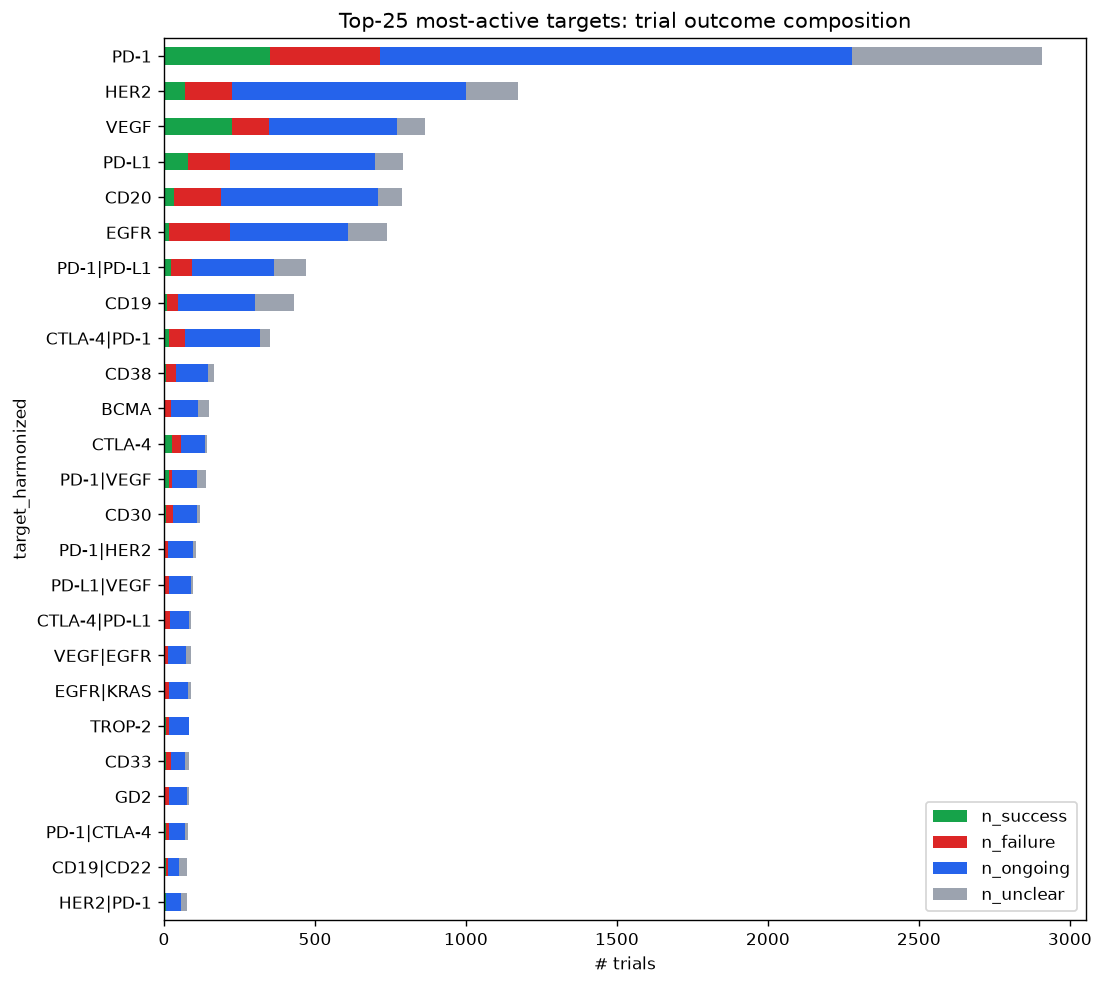

In [12]:
plot_df = TARGET_SCORECARD.sort_values("n_trials", ascending=False).head(25).set_index("target_harmonized")
plot_df = plot_df[["n_success", "n_failure", "n_ongoing", "n_unclear"]].iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 8))
plot_df.plot(kind="barh", stacked=True, ax=ax, color=["#16a34a", "#dc2626", "#2563eb", "#9ca3af"])
ax.set_xlabel("# trials"); ax.set_title("Top-25 most-active targets: trial outcome composition")
ax.legend(loc="lower right")
plt.tight_layout()

## Entry 13: Target x Modality Crowding Matrix (Top 20 Targets)

modality_code,ADC,ANTISENSE,BISPECIFIC,BiTE,CAR-T,MAB,OUT_OF_SCOPE,PROTAC
target_h,,,,,,,,
PD-1,6,0,14,1,29,2850,8,0
HER2,222,0,27,0,17,904,0,1
VEGF,0,0,7,0,1,854,1,0
PD-L1,2,0,10,0,3,769,7,0
CD20,0,0,7,0,14,767,0,0
EGFR,10,1,21,0,16,689,1,0
PD-1|PD-L1,0,0,8,0,3,455,4,1
CD19,1,0,1,2,393,35,0,0
CTLA-4|PD-1,0,0,75,0,2,274,0,0


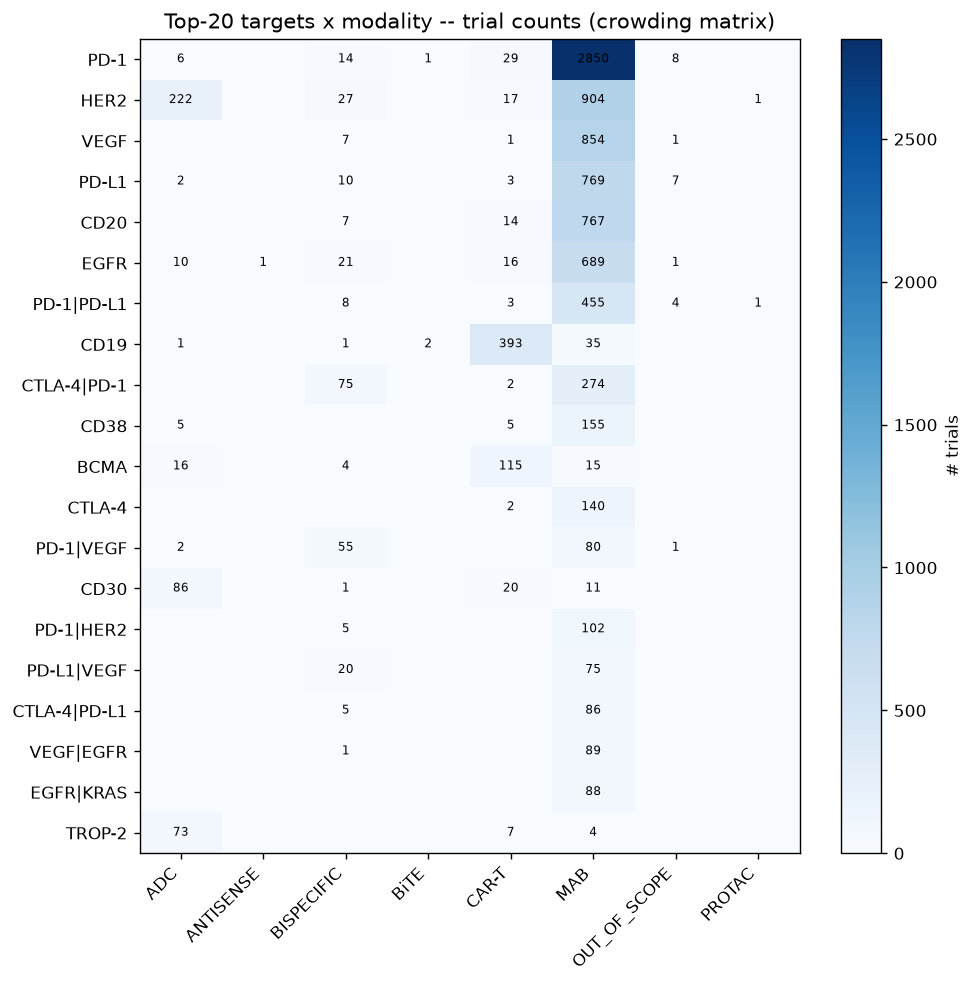

In [13]:
top20 = TARGET_SCORECARD.sort_values("n_trials", ascending=False).head(20)["target_harmonized"].tolist()
mat = df[df["target_h"].isin(top20)].pivot_table(index="target_h", columns="modality_code", values="nct", aggfunc="count", fill_value=0)
mat = mat.reindex(top20)
display(mat, name="entry13_target_modality_matrix")

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(mat.values, cmap="Blues", aspect="auto")
ax.set_xticks(range(len(mat.columns))); ax.set_xticklabels(mat.columns, rotation=45, ha="right")
ax.set_yticks(range(len(mat.index))); ax.set_yticklabels(mat.index)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        v = mat.values[i, j]
        if v > 0:
            ax.text(j, i, int(v), ha="center", va="center", fontsize=7)
ax.set_title("Top-20 targets x modality -- trial counts (crowding matrix)")
plt.colorbar(im, ax=ax, label="# trials")
plt.tight_layout()

## Entry 14: Solid-Tumor-Type x Modality Landscape

modality_code,ADC,ANTISENSE,BISPECIFIC,BiTE,CAR-T,MAB,MULTISPECIFIC,OUT_OF_SCOPE,PROTAC,RADIOLIGAND,Total
tumor_type,,,,,,,,,,,
Lung_Other,305.0,0.0,211.0,12.0,71.0,2298.0,1.0,38.0,0.0,3.0,2939.0
NSCLC,263.0,0.0,187.0,6.0,31.0,1859.0,2.0,6.0,0.0,1.0,2355.0
Breast,406.0,0.0,64.0,2.0,49.0,1578.0,1.0,8.0,4.0,2.0,2114.0
SCLC,229.0,0.0,180.0,7.0,40.0,1590.0,1.0,13.0,0.0,1.0,2061.0
Colorectal,56.0,0.0,85.0,2.0,55.0,1251.0,1.0,1.0,0.0,2.0,1453.0
Gastric_Esophageal,122.0,0.0,83.0,3.0,57.0,821.0,0.0,5.0,0.0,2.0,1093.0
HNSCC,62.0,1.0,54.0,1.0,7.0,788.0,1.0,5.0,0.0,1.0,920.0
Melanoma,27.0,0.0,31.0,2.0,41.0,666.0,0.0,7.0,0.0,0.0,774.0
Pancreatic,59.0,0.0,41.0,2.0,66.0,460.0,0.0,2.0,0.0,1.0,631.0


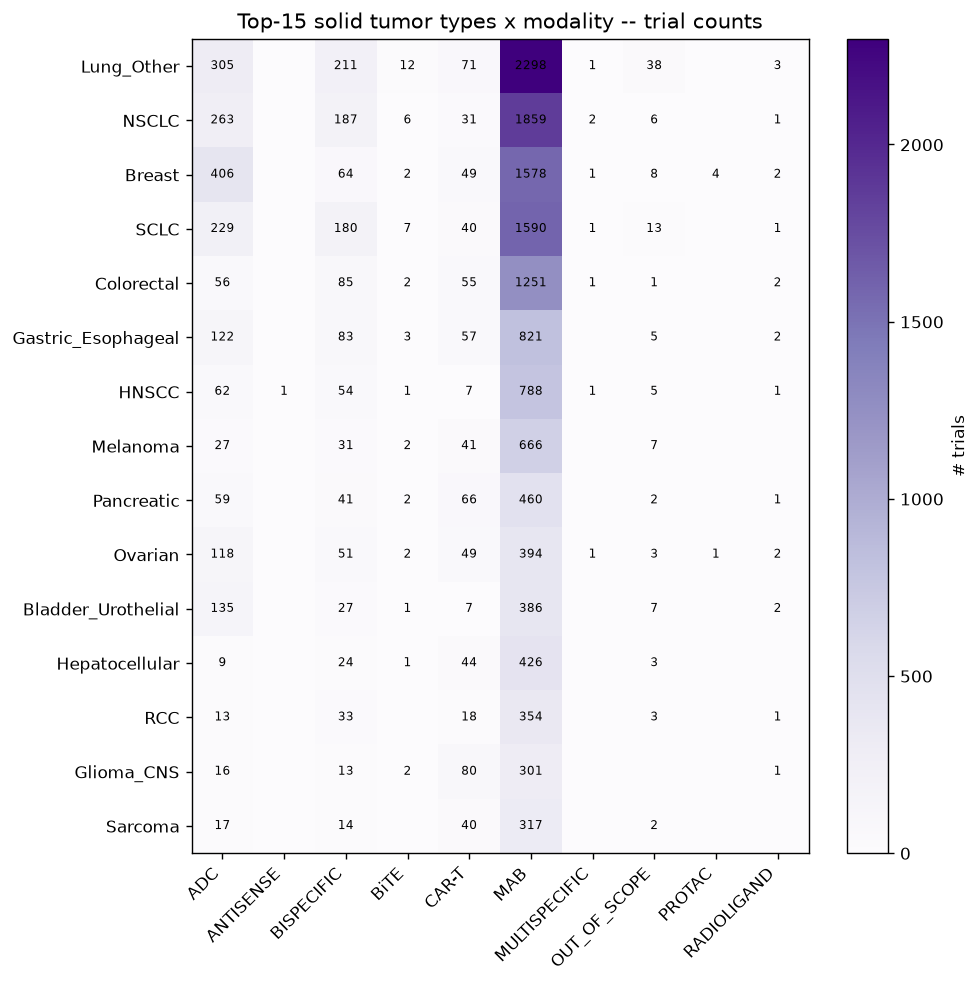

In [14]:
q = con.sql('''
    SELECT tumor_type, modality_code, COUNT(*) AS n_trials
    FROM tumor_junction
    WHERE tumor_type NOT LIKE 'Hematologic%' AND tumor_type <> 'Solid_Tumor_Basket'
    GROUP BY 1,2
''').df()
pivot = q.pivot_table(index="tumor_type", columns="modality_code", values="n_trials", fill_value=0)
pivot["Total"] = pivot.sum(axis=1)
pivot = pivot.sort_values("Total", ascending=False)
display(pivot, name="entry14_tumor_modality_matrix")

top15 = pivot.head(15).drop(columns="Total")
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(top15.values, cmap="Purples", aspect="auto")
ax.set_xticks(range(len(top15.columns))); ax.set_xticklabels(top15.columns, rotation=45, ha="right")
ax.set_yticks(range(len(top15.index))); ax.set_yticklabels(top15.index)
for i in range(top15.shape[0]):
    for j in range(top15.shape[1]):
        v = top15.values[i, j]
        if v > 0:
            ax.text(j, i, int(v), ha="center", va="center", fontsize=7)
ax.set_title("Top-15 solid tumor types x modality -- trial counts")
plt.colorbar(im, ax=ax, label="# trials")
plt.tight_layout()

## Entry 15: Top Targets per Solid Tumor Type

In [15]:
q = con.sql('''
    WITH agg AS (
      SELECT tumor_type, target_h AS target_harmonized, COUNT(*) AS n_trials
      FROM tumor_junction
      WHERE tumor_type NOT LIKE 'Hematologic%' AND tumor_type <> 'Solid_Tumor_Basket' AND target_h IS NOT NULL
      GROUP BY 1,2
    ), ranked AS (
      SELECT *, ROW_NUMBER() OVER (PARTITION BY tumor_type ORDER BY n_trials DESC) AS rnk,
             SUM(n_trials) OVER (PARTITION BY tumor_type) AS tumor_total
      FROM agg
    )
    SELECT tumor_type, target_harmonized, n_trials, tumor_total FROM ranked
    WHERE rnk <= 5 AND tumor_total >= 20
    ORDER BY tumor_total DESC, n_trials DESC
''').df()
display(q, name="entry15_top_targets_per_tumor_type")

,tumor_type,target_harmonized,n_trials,tumor_total
0,Lung_Other,PD-1,678,2853.0
1,Lung_Other,PD-L1,277,2853.0
2,Lung_Other,VEGF,272,2853.0
3,Lung_Other,EGFR,183,2853.0
4,Lung_Other,PD-1|PD-L1,146,2853.0
5,NSCLC,PD-1,562,2283.0
6,NSCLC,PD-L1,195,2283.0
7,NSCLC,VEGF,186,2283.0
8,NSCLC,EGFR,149,2283.0
9,NSCLC,PD-1|PD-L1,129,2283.0


## Entry 16: Chart -- Top Targets per Solid Tumor Type (Small Multiples)

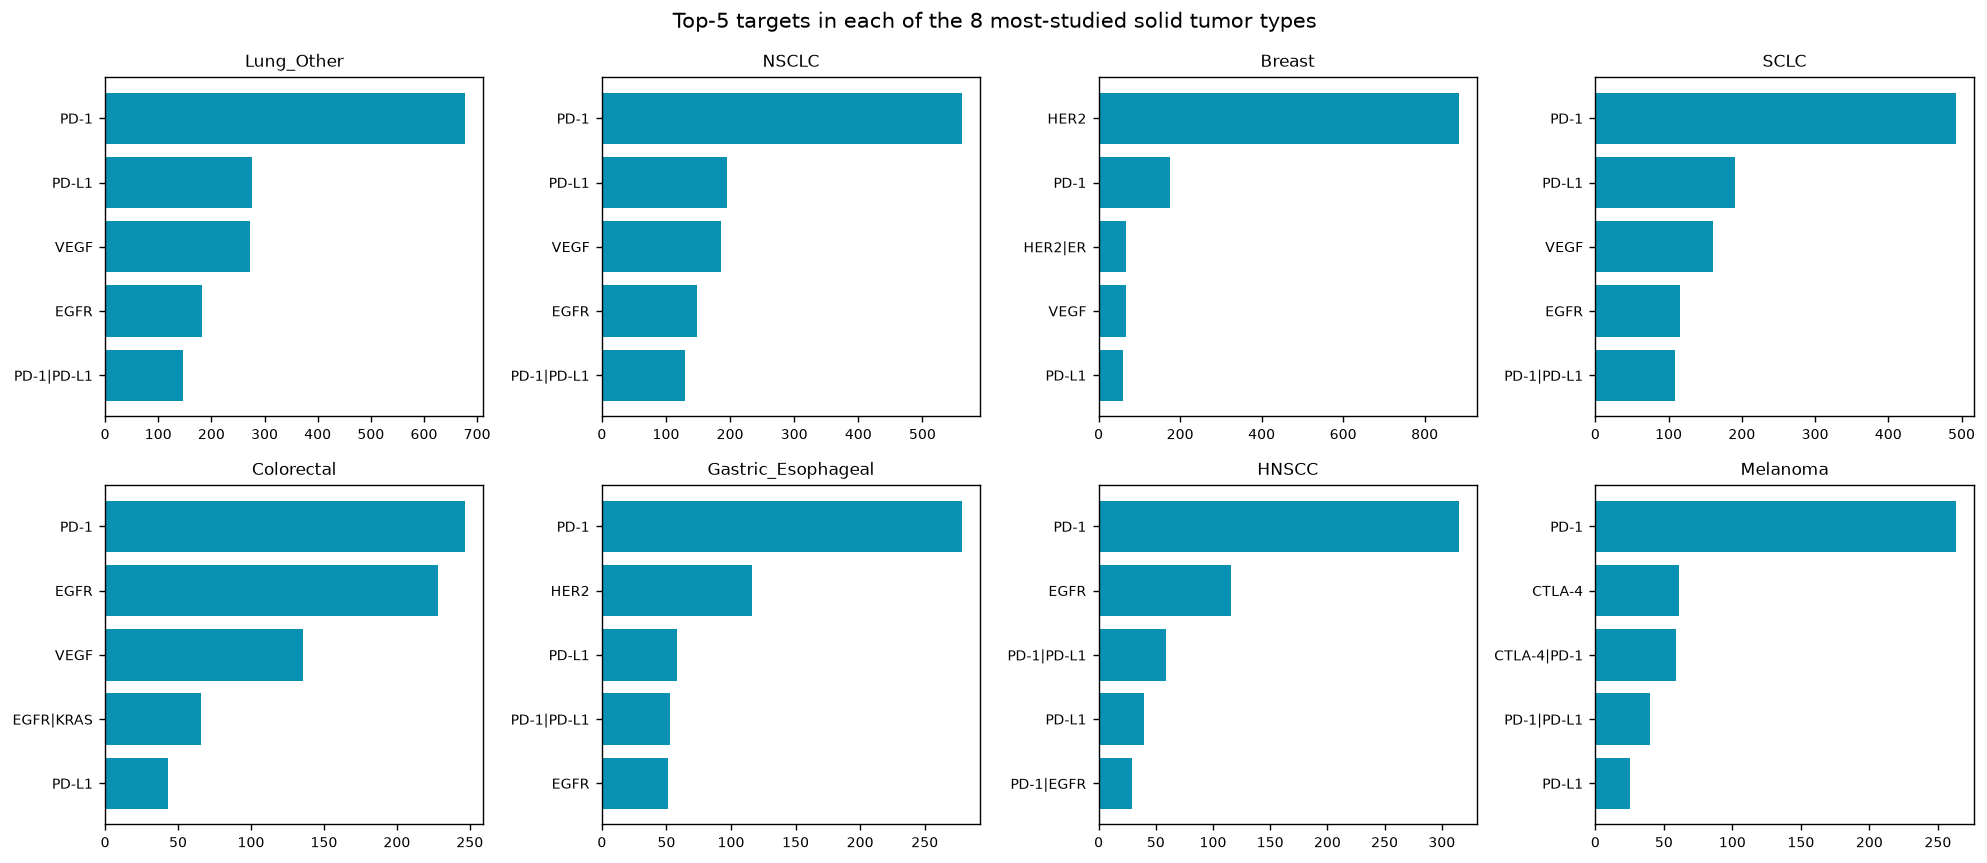

In [16]:
q = con.sql('''
    WITH agg AS (
      SELECT tumor_type, target_h AS target_harmonized, COUNT(*) AS n_trials
      FROM tumor_junction
      WHERE tumor_type NOT LIKE 'Hematologic%' AND tumor_type <> 'Solid_Tumor_Basket' AND target_h IS NOT NULL
      GROUP BY 1,2
    ), ranked AS (
      SELECT *, ROW_NUMBER() OVER (PARTITION BY tumor_type ORDER BY n_trials DESC) AS rnk,
             SUM(n_trials) OVER (PARTITION BY tumor_type) AS tumor_total
      FROM agg
    )
    SELECT tumor_type, target_harmonized, n_trials, tumor_total FROM ranked
    WHERE rnk <= 5 AND tumor_total >= 20
    ORDER BY tumor_total DESC, n_trials DESC
''').df()
top_tumors = q.drop_duplicates("tumor_type").sort_values("tumor_total", ascending=False)["tumor_type"].head(8).tolist()
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, tt in zip(axes.flat, top_tumors):
    sub = q[q["tumor_type"] == tt].sort_values("n_trials")
    ax.barh(sub["target_harmonized"], sub["n_trials"], color="#0891b2")
    ax.set_title(tt, fontsize=10)
    ax.tick_params(labelsize=8)
plt.suptitle("Top-5 targets in each of the 8 most-studied solid tumor types")
plt.tight_layout()

## Entry 17: Per-Tumor-Type Target Outcome Scorecard (Solid Tumors, Overall)

In [17]:
q = con.sql('''
    SELECT tumor_type, target_h AS target_harmonized,
           COUNT(*) AS n_trials,
           SUM(CASE WHEN outcome_bucket='Success' THEN 1 ELSE 0 END) AS n_success,
           SUM(CASE WHEN outcome_bucket='Failure' THEN 1 ELSE 0 END) AS n_failure,
           SUM(CASE WHEN outcome_bucket='Ongoing/Pending' THEN 1 ELSE 0 END) AS n_ongoing
    FROM tumor_junction
    WHERE tumor_type NOT LIKE 'Hematologic%' AND tumor_type <> 'Solid_Tumor_Basket' AND target_h IS NOT NULL
    GROUP BY 1,2
    HAVING COUNT(*) >= 3
    ORDER BY n_trials DESC
''').df()
TUMOR_TARGET_SCORECARD = q
display(q.head(50), name="entry17_tumor_target_outcome")
print(f"{len(q)} target x solid-tumor-type combinations with >=3 trials (full table exported to CSV).")

748 target x solid-tumor-type combinations with >=3 trials (full table exported to CSV).


,tumor_type,target_harmonized,n_trials,n_success,n_failure,n_ongoing
0,Breast,HER2,884,57.0,118.0,599.0
1,Lung_Other,PD-1,678,265.0,81.0,237.0
2,NSCLC,PD-1,562,233.0,62.0,191.0
3,SCLC,PD-1,492,200.0,60.0,161.0
4,HNSCC,PD-1,315,29.0,42.0,197.0
5,Gastric_Esophageal,PD-1,279,21.0,25.0,160.0
6,Lung_Other,PD-L1,277,65.0,44.0,149.0
7,Lung_Other,VEGF,272,191.0,18.0,45.0
8,Melanoma,PD-1,263,39.0,53.0,126.0
9,Colorectal,PD-1,247,21.0,34.0,149.0


## Entry 18: Per-Tumor-Type Target Outcome BY PHASE (1/2/3) -- Solid Tumors

In [18]:
# Same as Entry 9 but sliced BY solid tumor type -- e.g. "Target X
# succeeded in Phase 2 NSCLC trials but failed in Phase 2 breast trials."
q = con.sql('''
    SELECT tumor_type, target_h AS target_harmonized, phase_group, outcome_bucket, COUNT(*) AS n
    FROM tumor_junction
    WHERE tumor_type NOT LIKE 'Hematologic%' AND tumor_type <> 'Solid_Tumor_Basket'
      AND target_h IS NOT NULL AND phase_group IN ('Phase 1','Phase 2','Phase 3')
    GROUP BY 1,2,3,4
''').df()
wide = q.pivot_table(index=["tumor_type", "target_harmonized"], columns=["phase_group", "outcome_bucket"], values="n", fill_value=0)
wide.columns = [f"{p.replace('Phase ', 'Ph')}_{o.replace('/', '_')}" for p, o in wide.columns]
wide["grand_total"] = wide.sum(axis=1)
TUMOR_TARGET_PHASE_XTAB = wide[wide["grand_total"] >= 4].sort_values("grand_total", ascending=False)
display(TUMOR_TARGET_PHASE_XTAB.drop(columns="grand_total").head(60), name="entry18_tumor_target_phase_xtab")
print(f"{len(TUMOR_TARGET_PHASE_XTAB)} tumor-type x target combinations with >=4 phase-tagged trials.")

545 tumor-type x target combinations with >=4 phase-tagged trials.


Ph1_Failure  Ph1_Ongoing_Pending  Ph1_Success  Ph1_Unclear  Ph2_Failure  Ph2_Ongoing_Pending  Ph2_Success  Ph2_Unclear  \
tumor_type          target_harmonized                                                                                                                           
Breast              HER2                      24.0                 72.0         10.0          1.0         76.0                283.0         25.0         44.0   
Lung_Other          PD-1                      23.0                 48.0         56.0         13.0         45.0                120.0        144.0         43.0   
NSCLC               PD-1                      19.0                 37.0         51.0         11.0         32.0                 92.0        132.0         41.0   
SCLC                PD-1                      19.0                 27.0         43.0          9.0         32.0                 81.0        113.0         37.0   
HNSCC               PD-1                      15.0                 36.0         16.0          4.0         23.0                126.0         11.0         29.0   
Lung_Other          PD-L1                     13.0                 16.0         13.0          1.0         26.0                 77.0         37.0         12.0   
                    VEGF                       2.0                  7.0         21.0          2.0         13.0                 30.0        121.0          9.0   
Gastric_Esophageal  PD-1                      10.0                 26.0          6.0          2.0         12.0                 95.0         14.0         45.0   
Melanoma            PD-1                      14.0                 45.0         16.0         12.0         32.0                 66.0         22.0         20.0   
Colorectal          PD-1                      15.0                 23.0          8.0          6.0         19.0                100.0         12.0         25.0   
                    EGFR                      19.0                 19.0          0.0          5.0         34.0                 73.0          1.0         20.0   
NSCLC               PD-L1                      7.0                 12.0          8.0          1.0         19.0                 48.0         38.0          7.0   
SCLC                PD-L1                      8.0                  8.0         12.0          1.0         17.0                 53.0         26.0         10.0   
Breast              PD-1                      15.0                 25.0         10.0          4.0         24.0                 58.0          8.0         11.0   
Lung_Other          EGFR                      27.0                 17.0          2.0          5.0         66.0                 31.0          3.0          5.0   
NSCLC               VEGF                       2.0                  3.0         15.0          2.0          6.0                 11.0         82.0          6.0   
SCLC                VEGF                       2.0                  3.0         11.0          2.0          4.0                 12.0         74.0          5.0   
Bladder_Urothelial  PD-1                      11.0                 28.0         12.0          2.0         13.0                 44.0         10.0         10.0   
NSCLC               EGFR                      22.0                 14.0          2.0          5.0         51.0                 21.0          2.0          4.0   
Lung_Other          PD-1|PD-L1                 8.0                 11.0          0.0          4.0         13.0                 46.0          4.0         12.0   
RCC                 PD-1                       8.0                 17.0         13.0          4.0         11.0                 42.0         12.0         10.0   
Hepatocellular      PD-1                       5.0                  7.0          6.0          8.0         10.0                 37.0          8.0         25.0   
NSCLC               PD-1|PD-L1                 8.0                 10.0          0.0          4.0         12.0                 42.0          4.0         10.0   
Colorectal    

## Entry 19: Regimen Divergence -- Same Target, Same Tumor Type -- IO-Combo vs Monotherapy/All-Comers

In [19]:
# The refined ask: "same target succeeded WITH IO but failed as
# all-comers/monotherapy IN THE SAME POPULATION". We control for
# population by joining on tumor_type as well as target -- not just
# target alone (which could mix populations and produce false divergence).
def regimen_bucket(is_combo, partner_class):
    ic = str(is_combo)
    if ic == "True":
        pc = str(partner_class) if pd.notna(partner_class) else ""
        return "IO-combo" if "IO" in pc else "Non-IO-combo (chemo/TKI/other)"
    if ic == "False":
        return "Monotherapy/all-comers"
    return "Unknown regimen"

tj = tumor_junction.copy()
tj["regimen_bucket"] = [regimen_bucket(a, b) for a, b in zip(tj["is_combo"], tj["combo_partner_class"])]

q = tj[tj["regimen_bucket"].isin(["IO-combo", "Monotherapy/all-comers"]) &
       (tj["tumor_type"] != "Solid_Tumor_Basket") & ~tj["tumor_type"].str.startswith("Hematologic") &
       tj["target_h"].notna()].groupby(["target_h", "tumor_type", "regimen_bucket", "outcome_bucket"]).size().reset_index(name="n")

piv_t = q.pivot_table(index=["target_h", "tumor_type"], columns="regimen_bucket", values="n", aggfunc="sum", fill_value=0)
succ = q[q["outcome_bucket"] == "Success"].pivot_table(index=["target_h", "tumor_type"], columns="regimen_bucket", values="n", fill_value=0)
fail = q[q["outcome_bucket"] == "Failure"].pivot_table(index=["target_h", "tumor_type"], columns="regimen_bucket", values="n", fill_value=0)

div = pd.DataFrame({
    "n_trials_IO_combo": piv_t.get("IO-combo", 0), "n_success_IO_combo": succ.get("IO-combo", 0), "n_failure_IO_combo": fail.get("IO-combo", 0),
    "n_trials_mono": piv_t.get("Monotherapy/all-comers", 0), "n_success_mono": succ.get("Monotherapy/all-comers", 0), "n_failure_mono": fail.get("Monotherapy/all-comers", 0),
}).fillna(0)
div = div[(div["n_trials_IO_combo"] >= 1) & (div["n_trials_mono"] >= 1)]
div["divergence_flag"] = np.where(
    (div["n_success_IO_combo"] > 0) & (div["n_failure_mono"] > 0) & (div["n_success_mono"] == 0),
    "IO-combo succeeds, all-comers fails (SAME tumor type)",
    np.where((div["n_success_mono"] > 0) & (div["n_failure_IO_combo"] > 0) & (div["n_success_IO_combo"] == 0),
             "All-comers succeeds, IO-combo fails (SAME tumor type)", "No clear divergence"))
REGIMEN_DIVERGENCE_MATCHED = div.reset_index().rename(columns={"target_h": "target_harmonized"}).sort_values("n_trials_IO_combo", ascending=False)
display(REGIMEN_DIVERGENCE_MATCHED, name="entry19_regimen_divergence_population_matched")

flagged = REGIMEN_DIVERGENCE_MATCHED[REGIMEN_DIVERGENCE_MATCHED["divergence_flag"] != "No clear divergence"]
print(f"\n{len(flagged)} target x tumor-type pairs show a population-matched IO-combo vs all-comers divergence, "
      f"out of {len(REGIMEN_DIVERGENCE_MATCHED)} pairs with activity in both regimens.")
display(flagged, name="entry19_regimen_divergence_flagged")


8 target x tumor-type pairs show a population-matched IO-combo vs all-comers divergence, out of 105 pairs with activity in both regimens.


,target_harmonized,tumor_type,n_trials_IO_combo,n_success_IO_combo,n_failure_IO_combo,n_trials_mono,n_success_mono,n_failure_mono,divergence_flag
61,PD-1,Lung_Other,46,44.0,1.0,97,77.0,5.0,No clear divergence
64,PD-1,NSCLC,39,38.0,0.0,81,67.0,3.0,No clear divergence
69,PD-1,SCLC,32,31.0,0.0,65,55.0,3.0,No clear divergence
80,PD-L1,Lung_Other,13,12.0,1.0,38,22.0,5.0,No clear divergence
82,PD-L1,NSCLC,11,10.0,1.0,24,18.0,3.0,No clear divergence
86,PD-L1,SCLC,8,7.0,1.0,26,18.0,4.0,No clear divergence
20,EGFR,Lung_Other,6,0.0,6.0,20,0.0,19.0,No clear divergence
21,EGFR,NSCLC,6,0.0,6.0,18,0.0,17.0,No clear divergence
93,TROP-2-SN38,Lung_Other,5,0.0,5.0,3,0.0,3.0,No clear divergence
23,EGFR,SCLC,5,0.0,5.0,12,0.0,11.0,No clear divergence


,target_harmonized,tumor_type,n_trials_IO_combo,n_success_IO_combo,n_failure_IO_combo,n_trials_mono,n_success_mono,n_failure_mono,divergence_flag
36,HER2,Lung_Other,3,1.0,2.0,5,0.0,5.0,"IO-combo succeeds, all-comers fails (SAME tumor type)"
38,HER2,SCLC,2,1.0,1.0,2,0.0,2.0,"IO-combo succeeds, all-comers fails (SAME tumor type)"
49,MET,Lung_Other,2,0.0,2.0,1,1.0,0.0,"All-comers succeeds, IO-combo fails (SAME tumor type)"
50,MET,NSCLC,2,0.0,2.0,1,1.0,0.0,"All-comers succeeds, IO-combo fails (SAME tumor type)"
51,MET,SCLC,2,0.0,2.0,1,1.0,0.0,"All-comers succeeds, IO-combo fails (SAME tumor type)"
37,HER2,NSCLC,2,1.0,1.0,2,0.0,2.0,"IO-combo succeeds, all-comers fails (SAME tumor type)"
75,PD-L1,Breast,1,0.0,1.0,2,1.0,1.0,"All-comers succeeds, IO-combo fails (SAME tumor type)"
78,PD-L1,HNSCC,1,0.0,1.0,5,3.0,1.0,"All-comers succeeds, IO-combo fails (SAME tumor type)"


## Entry 20: Chart -- Population-Matched IO-Combo vs All-Comers Success-Rate Divergence

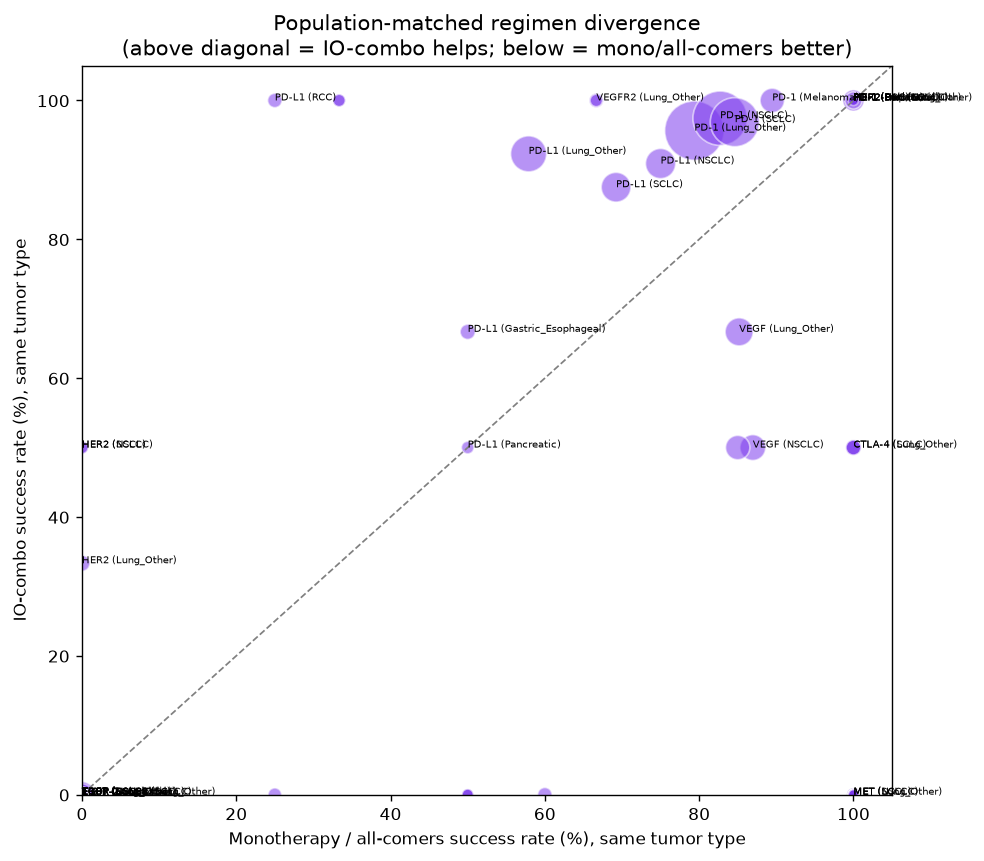

In [20]:
plot_df = REGIMEN_DIVERGENCE_MATCHED.copy()
plot_df["success_rate_IO"] = plot_df["n_success_IO_combo"] / plot_df["n_trials_IO_combo"] * 100
plot_df["success_rate_mono"] = plot_df["n_success_mono"] / plot_df["n_trials_mono"] * 100
plot_df["label"] = plot_df["target_harmonized"] + " (" + plot_df["tumor_type"] + ")"

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(plot_df["success_rate_mono"], plot_df["success_rate_IO"],
           s=(plot_df["n_trials_IO_combo"] + plot_df["n_trials_mono"]) * 8 + 20, alpha=0.55, c="#7c3aed", edgecolor="white")
for _, row in plot_df.head(40).iterrows():
    ax.annotate(row["label"], (row["success_rate_mono"], row["success_rate_IO"]), fontsize=6)
top_lim = max(plot_df["success_rate_mono"].max(), plot_df["success_rate_IO"].max(), 10) + 5
ax.plot([0, top_lim], [0, top_lim], "--", color="gray", linewidth=1)
ax.set_xlim(0, top_lim); ax.set_ylim(0, top_lim)
ax.set_xlabel("Monotherapy / all-comers success rate (%), same tumor type")
ax.set_ylabel("IO-combo success rate (%), same tumor type")
ax.set_title("Population-matched regimen divergence\n(above diagonal = IO-combo helps; below = mono/all-comers better)")
plt.tight_layout()

## Entry 21: Modality Divergence -- Same Target, Same Tumor Type -- Naked mAb vs ADC

In [21]:
# "Failed as a naked mAb monotherapy but succeeded once conjugated as an
# ADC" (or vice versa) -- controlled for tumor type to avoid conflating
# populations.
tj = tumor_junction[tumor_junction["modality_code"].isin(["MAB", "ADC"]) &
                    (tumor_junction["tumor_type"] != "Solid_Tumor_Basket") &
                    ~tumor_junction["tumor_type"].str.startswith("Hematologic") &
                    tumor_junction["target_h"].notna()]
q = tj.groupby(["target_h", "tumor_type", "modality_code", "outcome_bucket"]).size().reset_index(name="n")

piv_t = q.pivot_table(index=["target_h", "tumor_type"], columns="modality_code", values="n", aggfunc="sum", fill_value=0)
succ = q[q["outcome_bucket"] == "Success"].pivot_table(index=["target_h", "tumor_type"], columns="modality_code", values="n", fill_value=0)
fail = q[q["outcome_bucket"] == "Failure"].pivot_table(index=["target_h", "tumor_type"], columns="modality_code", values="n", fill_value=0)

mod_div = pd.DataFrame({
    "n_trials_MAB": piv_t.get("MAB", 0), "n_success_MAB": succ.get("MAB", 0), "n_failure_MAB": fail.get("MAB", 0),
    "n_trials_ADC": piv_t.get("ADC", 0), "n_success_ADC": succ.get("ADC", 0), "n_failure_ADC": fail.get("ADC", 0),
}).fillna(0)
mod_div = mod_div[(mod_div["n_trials_MAB"] >= 1) & (mod_div["n_trials_ADC"] >= 1)]
mod_div["divergence_flag"] = np.where(
    (mod_div["n_success_ADC"] > 0) & (mod_div["n_failure_MAB"] > 0) & (mod_div["n_success_MAB"] == 0),
    "ADC succeeds, naked mAb fails (SAME tumor type)",
    np.where((mod_div["n_success_MAB"] > 0) & (mod_div["n_failure_ADC"] > 0) & (mod_div["n_success_ADC"] == 0),
             "Naked mAb succeeds, ADC fails (SAME tumor type)", "No clear divergence"))
MODALITY_DIVERGENCE_MATCHED = mod_div.reset_index().rename(columns={"target_h": "target_harmonized"}).sort_values("n_trials_ADC", ascending=False)
display(MODALITY_DIVERGENCE_MATCHED, name="entry21_modality_divergence_population_matched")

flagged2 = MODALITY_DIVERGENCE_MATCHED[MODALITY_DIVERGENCE_MATCHED["divergence_flag"] != "No clear divergence"]
print(f"\n{len(flagged2)} target x tumor-type pairs show a population-matched naked-mAb vs ADC divergence, "
      f"out of {len(MODALITY_DIVERGENCE_MATCHED)} pairs with activity in both modalities.")
display(flagged2, name="entry21_modality_divergence_flagged")


25 target x tumor-type pairs show a population-matched naked-mAb vs ADC divergence, out of 121 pairs with activity in both modalities.


,target_harmonized,tumor_type,n_trials_MAB,n_success_MAB,n_failure_MAB,n_trials_ADC,n_success_ADC,n_failure_ADC,divergence_flag
37,HER2,Breast,712,43.0,100.0,151,12.0,14.0,No clear divergence
111,TROP-2,Breast,1,0.0,0.0,32,2.0,7.0,No clear divergence
41,HER2,Gastric_Esophageal,80,1.0,13.0,26,1.0,4.0,No clear divergence
89,NECTIN4,Bladder_Urothelial,3,0.0,0.0,21,1.0,2.0,No clear divergence
67,HER2|PD-1,Gastric_Esophageal,10,1.0,0.0,20,1.0,0.0,No clear divergence
36,HER2,Bladder_Urothelial,15,1.0,3.0,17,0.0,1.0,"Naked mAb succeeds, ADC fails (SAME tumor type)"
33,FOLR1,Ovarian,2,0.0,0.0,17,1.0,1.0,No clear divergence
45,HER2,Lung_Other,35,1.0,17.0,12,0.0,2.0,"Naked mAb succeeds, ADC fails (SAME tumor type)"
47,HER2,NSCLC,22,1.0,10.0,11,0.0,2.0,"Naked mAb succeeds, ADC fails (SAME tumor type)"
53,HER2,SCLC,19,1.0,9.0,10,0.0,2.0,"Naked mAb succeeds, ADC fails (SAME tumor type)"


,target_harmonized,tumor_type,n_trials_MAB,n_success_MAB,n_failure_MAB,n_trials_ADC,n_success_ADC,n_failure_ADC,divergence_flag
36,HER2,Bladder_Urothelial,15,1.0,3.0,17,0.0,1.0,"Naked mAb succeeds, ADC fails (SAME tumor type)"
45,HER2,Lung_Other,35,1.0,17.0,12,0.0,2.0,"Naked mAb succeeds, ADC fails (SAME tumor type)"
47,HER2,NSCLC,22,1.0,10.0,11,0.0,2.0,"Naked mAb succeeds, ADC fails (SAME tumor type)"
53,HER2,SCLC,19,1.0,9.0,10,0.0,2.0,"Naked mAb succeeds, ADC fails (SAME tumor type)"
70,HER2|PD-L1,Breast,10,0.0,2.0,9,1.0,2.0,"ADC succeeds, naked mAb fails (SAME tumor type)"
49,HER2,Ovarian,16,0.0,6.0,8,1.0,1.0,"ADC succeeds, naked mAb fails (SAME tumor type)"
39,HER2,Colorectal,20,0.0,6.0,6,1.0,1.0,"ADC succeeds, naked mAb fails (SAME tumor type)"
84,MET,SCLC,7,2.0,3.0,5,0.0,1.0,"Naked mAb succeeds, ADC fails (SAME tumor type)"
83,MET,NSCLC,7,2.0,3.0,5,0.0,1.0,"Naked mAb succeeds, ADC fails (SAME tumor type)"
82,MET,Lung_Other,7,2.0,3.0,5,0.0,1.0,"Naked mAb succeeds, ADC fails (SAME tumor type)"


## Entry 22: Chart -- Population-Matched Naked mAb vs ADC Success-Rate Divergence

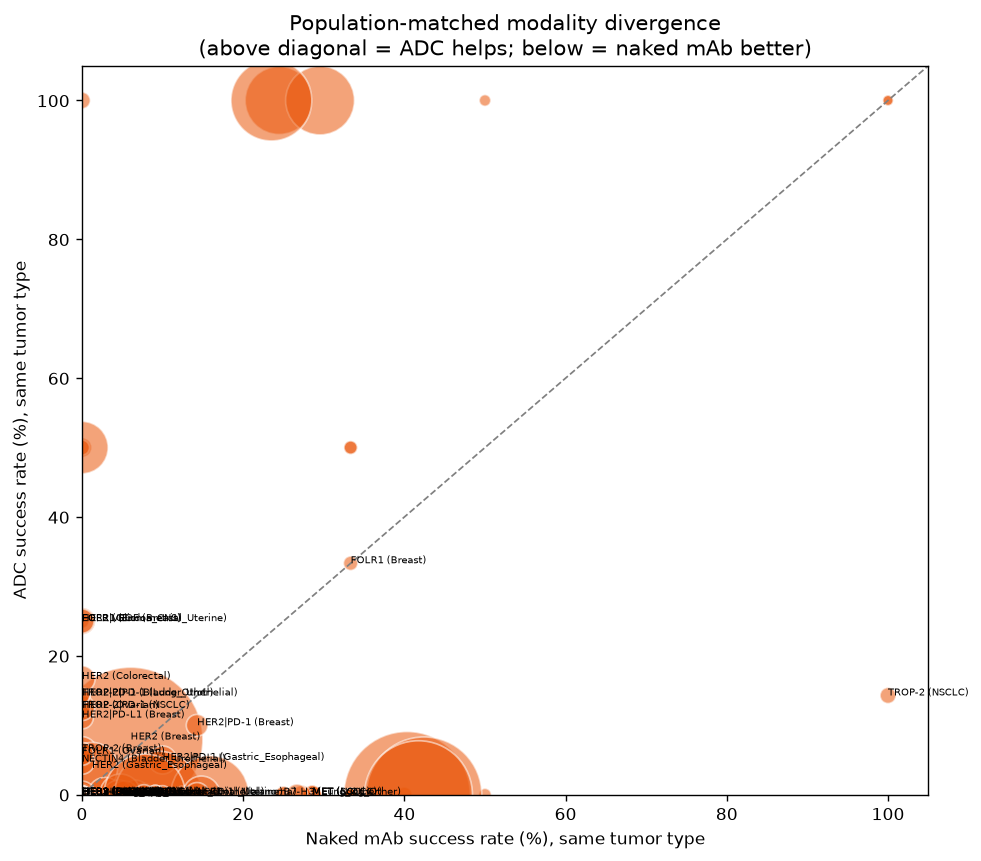

In [22]:
plot_df = MODALITY_DIVERGENCE_MATCHED.copy()
plot_df["success_rate_MAB"] = plot_df["n_success_MAB"] / plot_df["n_trials_MAB"] * 100
plot_df["success_rate_ADC"] = plot_df["n_success_ADC"] / plot_df["n_trials_ADC"] * 100
plot_df["label"] = plot_df["target_harmonized"] + " (" + plot_df["tumor_type"] + ")"

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(plot_df["success_rate_MAB"], plot_df["success_rate_ADC"],
           s=(plot_df["n_trials_MAB"] + plot_df["n_trials_ADC"]) * 8 + 20, alpha=0.55, c="#ea580c", edgecolor="white")
for _, row in plot_df.head(40).iterrows():
    ax.annotate(row["label"], (row["success_rate_MAB"], row["success_rate_ADC"]), fontsize=6)
top_lim = max(plot_df["success_rate_MAB"].max(), plot_df["success_rate_ADC"].max(), 10) + 5
ax.plot([0, top_lim], [0, top_lim], "--", color="gray", linewidth=1)
ax.set_xlim(0, top_lim); ax.set_ylim(0, top_lim)
ax.set_xlabel("Naked mAb success rate (%), same tumor type")
ax.set_ylabel("ADC success rate (%), same tumor type")
ax.set_title("Population-matched modality divergence\n(above diagonal = ADC helps; below = naked mAb better)")
plt.tight_layout()

## Entry 23: Combo-Partner-Class Divergence -- Chemo vs TKI vs IO vs Other vs Monotherapy

In [23]:
# Broader subtle-difference lens than IO-vs-mono alone: which combination
# PARTNER CLASS actually works best for each target?
def partner_class_bucket(is_combo, partner_class):
    if str(is_combo) != "True":
        return "Monotherapy"
    pc = str(partner_class) if pd.notna(partner_class) else ""
    if "IO" in pc:
        return "IO-combo"
    if "chemo" in pc:
        return "Chemo-combo"
    if "TKI" in pc:
        return "TKI-combo"
    if "other" in pc:
        return "Other-combo"
    return "Unspecified-combo"

df["partner_class_bucket"] = [partner_class_bucket(a, b) for a, b in zip(df["is_combo"], df["combo_partner_class"])]
con.register("trials", df)

q = con.sql('''
    SELECT target_h AS target_harmonized, partner_class_bucket,
           COUNT(*) AS n_trials,
           SUM(CASE WHEN outcome_bucket='Success' THEN 1 ELSE 0 END) AS n_success,
           SUM(CASE WHEN outcome_bucket='Failure' THEN 1 ELSE 0 END) AS n_failure
    FROM trials
    WHERE target_h IS NOT NULL AND partner_class_bucket <> 'Unspecified-combo'
    GROUP BY 1,2
    HAVING COUNT(*) >= 3
''').df()
q["success_rate_%"] = (q["n_success"] / q["n_trials"] * 100).round(1)
PARTNER_CLASS_TABLE = q.sort_values(["target_harmonized", "n_trials"], ascending=[True, False])
display(PARTNER_CLASS_TABLE, name="entry23_combo_partner_class_divergence")

# Targets tested across >=3 different partner-class buckets, ranked by
# spread between best and worst success rate -- the most "regimen-sensitive" targets.
spread = q.groupby("target_harmonized").agg(n_classes=("partner_class_bucket", "nunique"),
                                             best_rate=("success_rate_%", "max"),
                                             worst_rate=("success_rate_%", "min"),
                                             n_trials=("n_trials", "sum"))
spread["rate_spread"] = spread["best_rate"] - spread["worst_rate"]
spread = spread[spread["n_classes"] >= 3].sort_values("rate_spread", ascending=False)
display(spread.head(20), name="entry23_most_regimen_sensitive_targets")

,target_harmonized,partner_class_bucket,n_trials,n_success,n_failure,success_rate_%
191,ALK,Monotherapy,4,0.0,1.0,0.0
208,ALK|EGFR,Monotherapy,4,0.0,0.0,0.0
60,AR,Monotherapy,5,0.0,0.0,0.0
215,AXL-MMAE,Monotherapy,3,0.0,1.0,0.0
122,B7-H3,Monotherapy,60,1.0,5.0,1.7
16,B7-H3-Dxd,Monotherapy,4,1.0,0.0,25.0
205,B7-H3-Rezetecan,Monotherapy,6,1.0,1.0,16.7
2,B7-H3-TOP1i,Monotherapy,7,0.0,0.0,0.0
17,BCL-2,Monotherapy,4,0.0,0.0,0.0
112,BCL-2|BTK|CD20,Monotherapy,3,2.0,0.0,66.7


,n_classes,best_rate,worst_rate,n_trials,rate_spread
target_harmonized,,,,,
PD-L1,5,100.0,7.2,752,92.8
PD-1,5,100.0,8.1,2855,91.9
VEGF,4,100.0,14.0,854,86.0
VEGFR2,4,100.0,22.5,54,77.5
EGFR,4,33.3,0.0,730,33.3
HER2,3,33.3,0.0,1168,33.3


## Entry 24: ADC Payload Landscape -- Which Payloads Work, for Which Targets

In [24]:
q = con.sql('''
    SELECT target_h AS target_harmonized, payload_short,
           COUNT(*) AS n_trials,
           COUNT(DISTINCT lead_sponsor_golden) AS n_sponsors,
           SUM(CASE WHEN outcome_bucket='Success' THEN 1 ELSE 0 END) AS n_success,
           SUM(CASE WHEN outcome_bucket='Failure' THEN 1 ELSE 0 END) AS n_failure
    FROM trials
    WHERE modality_code = 'ADC' AND payload_short IS NOT NULL AND target_h IS NOT NULL
    GROUP BY 1,2
    ORDER BY n_trials DESC
''').df()
q["success_rate_%"] = (q["n_success"] / q["n_trials"] * 100).round(1)
ADC_PAYLOAD_TABLE = q
display(q.head(40), name="entry24_adc_payload_landscape")

payload_overall = con.sql('''
    SELECT payload_short, COUNT(*) AS n_trials, COUNT(DISTINCT target_h) AS n_targets,
           SUM(CASE WHEN outcome_bucket='Success' THEN 1 ELSE 0 END) AS n_success
    FROM trials WHERE modality_code='ADC' AND payload_short IS NOT NULL
    GROUP BY 1 ORDER BY n_trials DESC
''').df()
display(payload_overall, name="entry24_adc_payload_overall")

,target_harmonized,payload_short,n_trials,n_sponsors,n_success,n_failure,success_rate_%
0,HER2-Dxd,Dxd,22,15,13.0,1.0,59.1
1,HER2-MMAE,MMAE,21,14,1.0,1.0,4.8
2,TROP-2-Dxd,Dxd,17,7,16.0,0.0,94.1
3,TROP-2-KL610023,KL610023,14,11,5.0,0.0,35.7
4,TROP-2-SN38,SN38,14,12,1.0,11.0,7.1
5,MET-MMAE,MMAE,12,6,7.0,3.0,58.3
6,HER2-TOP1i,TOP1i,11,3,5.0,1.0,45.5
7,HER3-Dxd,Dxd,9,4,3.0,4.0,33.3
8,Tissue factor-MMAE,MMAE,8,4,0.0,0.0,0.0
9,B7-H3-TOP1i,TOP1i,8,5,0.0,0.0,0.0


,payload_short,n_trials,n_targets,n_success
0,MMAE,121,35,14.0
1,TOP1i,100,43,9.0
2,Dxd,65,11,33.0
3,Exatecan,38,22,0.0
4,KL610023,34,12,6.0
5,Auristatin,26,10,2.0
6,SN38,21,4,1.0
7,PBD,12,5,0.0
8,Rezetecan,11,4,3.0
9,MMAF,11,5,2.0


## Entry 25: Chart -- ADC Payload Class Overview & Top Payload x Target Pairings

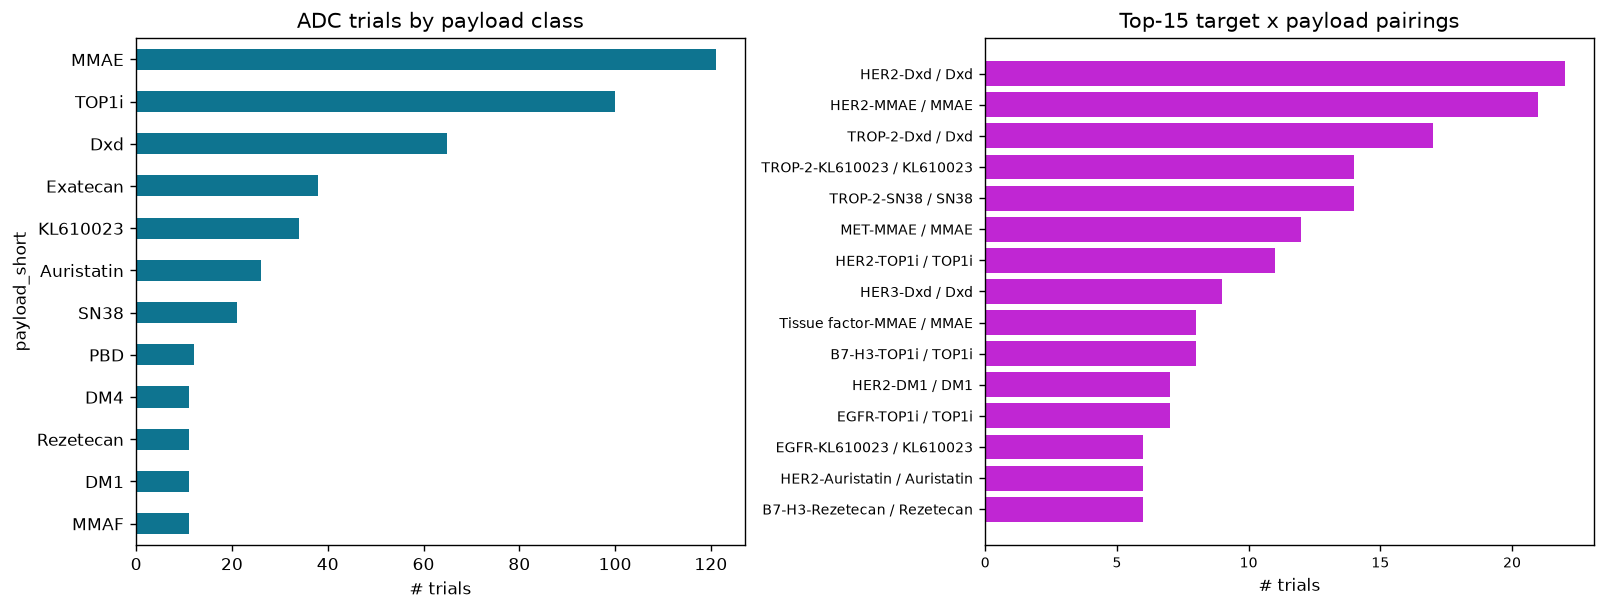

In [25]:
payload_overall = con.sql('''
    SELECT payload_short, COUNT(*) AS n_trials, COUNT(DISTINCT target_h) AS n_targets
    FROM trials WHERE modality_code='ADC' AND payload_short IS NOT NULL
    GROUP BY 1 ORDER BY n_trials DESC LIMIT 12
''').df()
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
payload_overall.set_index("payload_short")["n_trials"].sort_values().plot(kind="barh", ax=axes[0], color="#0e7490")
axes[0].set_title("ADC trials by payload class"); axes[0].set_xlabel("# trials")

top_pairs = ADC_PAYLOAD_TABLE.sort_values("n_trials", ascending=False).head(15).iloc[::-1]
labels = top_pairs["target_harmonized"] + " / " + top_pairs["payload_short"]
axes[1].barh(labels, top_pairs["n_trials"], color="#c026d3")
axes[1].set_title("Top-15 target x payload pairings"); axes[1].set_xlabel("# trials")
axes[1].tick_params(labelsize=8)
plt.tight_layout()

## Entry 26: Line-of-Therapy Divergence -- Same Target, 1L vs 2L+

In [26]:
q = con.sql('''
    SELECT target_h AS target_harmonized, m_line_of_therapy,
           COUNT(*) AS n_trials,
           SUM(CASE WHEN outcome_bucket='Success' THEN 1 ELSE 0 END) AS n_success,
           SUM(CASE WHEN outcome_bucket='Failure' THEN 1 ELSE 0 END) AS n_failure
    FROM trials
    WHERE target_h IS NOT NULL AND m_line_of_therapy IN ('1L','2L')
    GROUP BY 1,2
''').df()
piv_t = q.pivot_table(index="target_harmonized", columns="m_line_of_therapy", values="n_trials", fill_value=0)
piv_s = q.pivot_table(index="target_harmonized", columns="m_line_of_therapy", values="n_success", fill_value=0)
piv_f = q.pivot_table(index="target_harmonized", columns="m_line_of_therapy", values="n_failure", fill_value=0)

lot_div = pd.DataFrame({
    "n_trials_1L": piv_t.get("1L", 0), "n_success_1L": piv_s.get("1L", 0), "n_failure_1L": piv_f.get("1L", 0),
    "n_trials_2L": piv_t.get("2L", 0), "n_success_2L": piv_s.get("2L", 0), "n_failure_2L": piv_f.get("2L", 0),
}).fillna(0)
lot_div = lot_div[(lot_div["n_trials_1L"] >= 1) & (lot_div["n_trials_2L"] >= 1)]
lot_div = lot_div.sort_values(["n_trials_1L", "n_trials_2L"], ascending=False)
display(lot_div, name="entry26_line_of_therapy_divergence")
print(f"{len(lot_div)} targets have annotated activity in both 1L and 2L+ settings "
      f"(m_line_of_therapy is sparsely populated: {df['m_line_of_therapy'].notna().sum():,}/{len(df):,} rows).")

112 targets have annotated activity in both 1L and 2L+ settings (m_line_of_therapy is sparsely populated: 3,167/16,648 rows).


,n_trials_1L,n_success_1L,n_failure_1L,n_trials_2L,n_success_2L,n_failure_2L
target_harmonized,,,,,,
PD-1,188.0,5.0,23.0,175.0,6.0,20.0
CD20,130.0,9.0,19.0,187.0,3.0,58.0
HER2,69.0,3.0,9.0,50.0,3.0,12.0
VEGF,66.0,3.0,14.0,36.0,3.0,7.0
PD-L1,57.0,3.0,8.0,35.0,2.0,10.0
PD-1|PD-L1,55.0,1.0,5.0,35.0,1.0,3.0
EGFR,53.0,1.0,11.0,24.0,1.0,6.0
CTLA-4|PD-1,37.0,1.0,2.0,27.0,1.0,8.0
CD20|BTK,27.0,0.0,4.0,14.0,1.0,3.0


## Entry 27: Trial Termination-Reason Landscape -- Accrual vs Safety vs Efficacy vs Business

In [27]:
q = con.sql('''
    SELECT modality_code, stop_reason_bucket, COUNT(*) AS n
    FROM trials WHERE stop_reason_bucket IS NOT NULL
    GROUP BY 1,2
''').df()
pivot = q.pivot_table(index="modality_code", columns="stop_reason_bucket", values="n", fill_value=0)
display(pivot, name="entry27_termination_reason_by_modality")

by_target = con.sql('''
    SELECT target_h AS target_harmonized, stop_reason_bucket, COUNT(*) AS n
    FROM trials WHERE stop_reason_bucket IS NOT NULL AND target_h IS NOT NULL
    GROUP BY 1,2
''').df()
piv_target = by_target.pivot_table(index="target_harmonized", columns="stop_reason_bucket", values="n", fill_value=0)
piv_target["Total_terminations"] = piv_target.sum(axis=1)
piv_target = piv_target.sort_values("Total_terminations", ascending=False)
display(piv_target.head(25), name="entry27_termination_reason_by_target")

n_safety = int(q[q["stop_reason_bucket"] == "Safety/Toxicity"]["n"].sum())
n_efficacy = int(q[q["stop_reason_bucket"] == "Efficacy/Futility"]["n"].sum())
print(f"\nOf terminated trials with a mined reason: {n_safety} cite Safety/Toxicity, "
      f"{n_efficacy} cite Efficacy/Futility -- the rest are accrual, business/funding, "
      f"regulatory, or unspecified (i.e. most terminations are NOT clinical failures).")


Of terminated trials with a mined reason: 144 cite Safety/Toxicity, 90 cite Efficacy/Futility -- the rest are accrual, business/funding, regulatory, or unspecified (i.e. most terminations are NOT clinical failures).


stop_reason_bucket,Accrual/Enrollment,Business/Funding/Strategic,COVID/Logistics,Efficacy/Futility,Other/Unspecified,Regulatory/Administrative,Safety/Toxicity
modality_code,,,,,,,
ADC,37.0,71.0,1.0,4.0,49.0,3.0,7.0
BISPECIFIC,16.0,35.0,0.0,3.0,41.0,0.0,7.0
BiTE,4.0,6.0,0.0,0.0,5.0,0.0,0.0
CAR-T,38.0,19.0,1.0,6.0,78.0,6.0,9.0
MAB,589.0,360.0,6.0,77.0,588.0,29.0,121.0
MULTISPECIFIC,1.0,0.0,0.0,0.0,0.0,0.0,0.0
OUT_OF_SCOPE,5.0,1.0,0.0,0.0,2.0,0.0,0.0
RADIOLIGAND,1.0,1.0,0.0,0.0,1.0,0.0,0.0


stop_reason_bucket,Accrual/Enrollment,Business/Funding/Strategic,COVID/Logistics,Efficacy/Futility,Other/Unspecified,Regulatory/Administrative,Safety/Toxicity,Total_terminations
target_harmonized,,,,,,,,
PD-1,100.0,106.0,1.0,18.0,114.0,7.0,23.0,369.0
PD-L1,56.0,17.0,0.0,6.0,48.0,0.0,12.0,139.0
VEGF,64.0,7.0,0.0,5.0,39.0,4.0,9.0,128.0
CD20,57.0,16.0,1.0,2.0,37.0,1.0,5.0,119.0
HER2,49.0,10.0,0.0,3.0,40.0,2.0,8.0,112.0
EGFR,42.0,17.0,1.0,3.0,30.0,2.0,7.0,102.0
PD-1|PD-L1,14.0,16.0,0.0,6.0,17.0,1.0,10.0,64.0
CTLA-4|PD-1,16.0,10.0,0.0,1.0,18.0,1.0,2.0,48.0
CD38,10.0,4.0,0.0,2.0,15.0,1.0,2.0,34.0


## Entry 28: Chart -- Termination-Reason Mix, Overall and by Modality

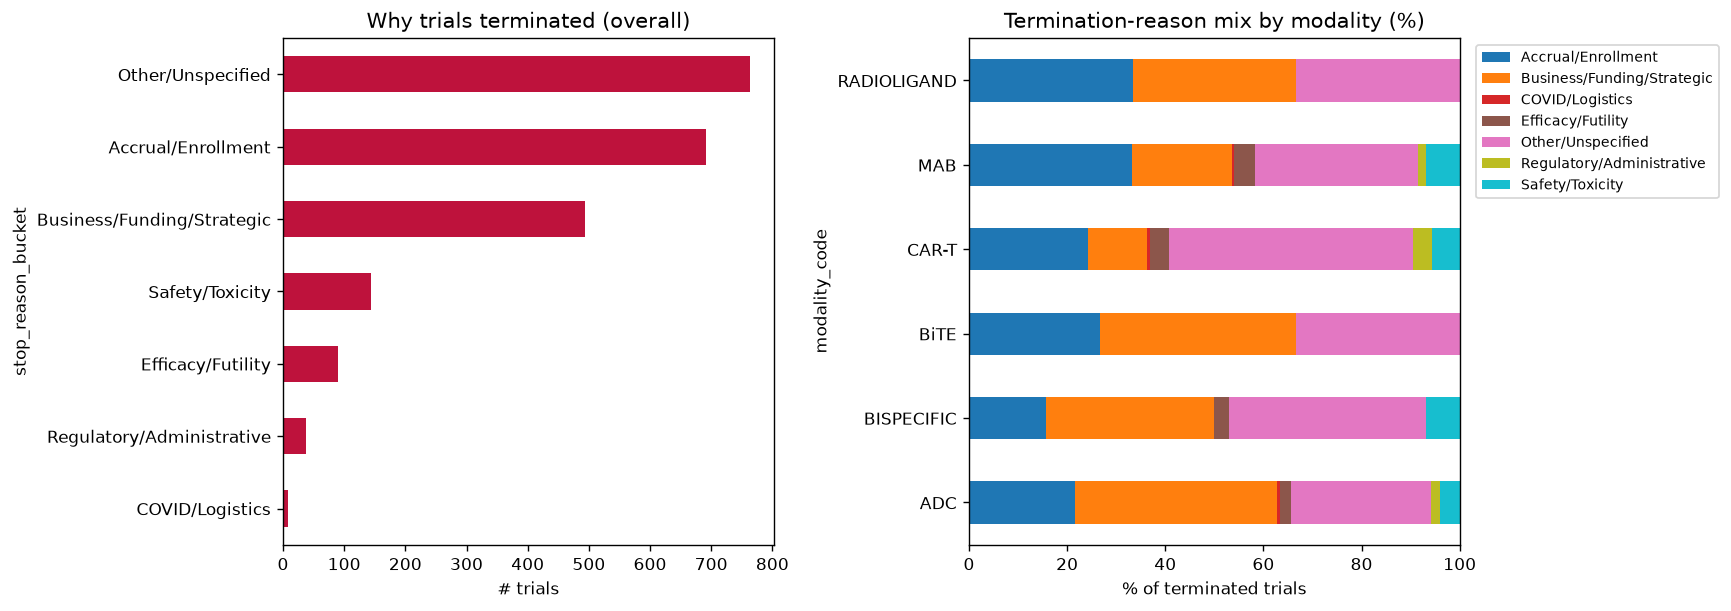

In [28]:
q = con.sql('''
    SELECT modality_code, stop_reason_bucket, COUNT(*) AS n
    FROM trials WHERE stop_reason_bucket IS NOT NULL
      AND modality_code IN ('MAB','ADC','BISPECIFIC','CAR-T','BiTE','RADIOLIGAND')
    GROUP BY 1,2
''').df()
pivot = q.pivot_table(index="modality_code", columns="stop_reason_bucket", values="n", fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

overall = con.sql("SELECT stop_reason_bucket, COUNT(*) n FROM trials WHERE stop_reason_bucket IS NOT NULL GROUP BY 1 ORDER BY 2 DESC").df()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
overall.set_index("stop_reason_bucket")["n"].sort_values().plot(kind="barh", ax=axes[0], color="#be123c")
axes[0].set_title("Why trials terminated (overall)"); axes[0].set_xlabel("# trials")

pivot_pct.plot(kind="barh", stacked=True, ax=axes[1], colormap="tab10")
axes[1].set_title("Termination-reason mix by modality (%)"); axes[1].set_xlabel("% of terminated trials")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()

## Entry 29: Sponsor Concentration & Competitive Intensity per Target

In [29]:
q = con.sql('''
    SELECT target_h AS target_harmonized, lead_sponsor_golden, COUNT(*) AS n
    FROM trials WHERE target_h IS NOT NULL AND lead_sponsor_golden IS NOT NULL
    GROUP BY 1,2
''').df()
rows = []
for target, g in q.groupby("target_harmonized"):
    shares = g["n"] / g["n"].sum()
    rows.append({
        "target_harmonized": target,
        "n_trials": int(g["n"].sum()),
        "n_sponsors": int(g["lead_sponsor_golden"].nunique()),
        "top_sponsor": g.loc[g["n"].idxmax(), "lead_sponsor_golden"],
        "top_sponsor_share_%": round(shares.max() * 100, 1),
        "hhi": round((shares ** 2).sum() * 10000, 0),
    })
conc = pd.DataFrame(rows)
conc = conc[conc["n_trials"] >= 5].sort_values("n_trials", ascending=False)
SPONSOR_CONCENTRATION = conc
display(conc.head(40), name="entry29_sponsor_concentration")
print("HHI > 2500 = highly concentrated (single-sponsor-dominated); HHI < 1500 = fragmented/competitive field.")

HHI > 2500 = highly concentrated (single-sponsor-dominated); HHI < 1500 = fragmented/competitive field.


,target_harmonized,n_trials,n_sponsors,top_sponsor,top_sponsor_share_%,hhi
993,PD-1,2903,978,Merck Sharp & Dohme LLC,5.0,86.0
752,HER2,1150,430,Hoffmann-La Roche,7.5,128.0
1465,VEGF,862,345,National Cancer Institute (NCI),14.7,309.0
1258,PD-L1,789,349,Hoffmann-La Roche,6.7,143.0
224,CD20,785,307,M.D. Anderson Cancer Center,6.1,140.0
604,EGFR,736,339,Eli Lilly and Company,5.2,92.0
1175,PD-1|PD-L1,471,266,Merck Sharp & Dohme LLC,4.2,90.0
176,CD19,432,209,Memorial Sloan Kettering Cancer Center,3.5,101.0
541,CTLA-4|PD-1,351,184,National Cancer Institute (NCI),8.8,196.0
346,CD38,165,97,Sanofi,9.7,233.0


## Entry 30: Momentum Analysis -- Targets Heating Up vs Cooling Down (Recent vs Prior Activity)

In [30]:
# Compares trial-start activity in the RECENT window (2022-2025) vs the
# PRIOR window (2015-2021) per target -- surfaces targets with rising
# momentum (recent entrants racing in) vs those going quiet (abandoned).
q = con.sql('''
    SELECT target_h AS target_harmonized,
           SUM(CASE WHEN start_year BETWEEN 2015 AND 2021 THEN 1 ELSE 0 END) AS n_prior,
           SUM(CASE WHEN start_year BETWEEN 2022 AND 2025 THEN 1 ELSE 0 END) AS n_recent,
           COUNT(DISTINCT CASE WHEN start_year BETWEEN 2022 AND 2025 THEN lead_sponsor_golden END) AS n_recent_sponsors
    FROM trials
    WHERE target_h IS NOT NULL
    GROUP BY 1
    HAVING n_prior + n_recent >= 5
''').df()
q["momentum_ratio"] = (q["n_recent"] + 1) / (q["n_prior"] + 1)

def momentum_label(row):
    if row["n_prior"] == 0 and row["n_recent"] >= 3:
        return "New wave (no prior activity, now active)"
    if row["momentum_ratio"] >= 2 and row["n_recent"] >= 3:
        return "Heating up (accelerating)"
    if row["n_recent"] == 0 and row["n_prior"] >= 3:
        return "Cooling down (gone quiet)"
    return "Steady"

q["momentum_label"] = q.apply(momentum_label, axis=1)
MOMENTUM_TABLE = q.sort_values("momentum_ratio", ascending=False)
display(MOMENTUM_TABLE.head(30), name="entry30_momentum_heating_up")
display(MOMENTUM_TABLE.sort_values("momentum_ratio").head(20), name="entry30_momentum_cooling_down")
print(MOMENTUM_TABLE["momentum_label"].value_counts().to_string())

momentum_label
Steady                                      138
Heating up (accelerating)                    39
Cooling down (gone quiet)                    11
New wave (no prior activity, now active)      8


,target_harmonized,n_prior,n_recent,n_recent_sponsors,momentum_ratio,momentum_label
58,BCMA|GPRC5D,0.0,19.0,14,20.000000,"New wave (no prior activity, now active)"
36,CD20|CD3|BTK,0.0,9.0,8,10.000000,"New wave (no prior activity, now active)"
160,HER2-TOP1i,0.0,9.0,2,10.000000,"New wave (no prior activity, now active)"
116,B7-H3-TOP1i,0.0,8.0,5,9.000000,"New wave (no prior activity, now active)"
80,PD-1|TROP-2,0.0,8.0,8,9.000000,"New wave (no prior activity, now active)"
194,CD38|BCL-2,0.0,5.0,4,6.000000,"New wave (no prior activity, now active)"
65,B7-H3-Rezetecan,0.0,5.0,1,6.000000,"New wave (no prior activity, now active)"
97,BCMA|CD3|GPRC5D,0.0,5.0,5,6.000000,"New wave (no prior activity, now active)"
87,CD20|CD3,8.0,44.0,30,5.000000,Heating up (accelerating)
182,DLL3|CD3,4.0,23.0,12,4.800000,Heating up (accelerating)


,target_harmonized,n_prior,n_recent,n_recent_sponsors,momentum_ratio,momentum_label
165,PD-1|BTK,13.0,0.0,0,0.071429,Cooling down (gone quiet)
31,PD-1|ER|HER2,7.0,0.0,0,0.125000,Cooling down (gone quiet)
157,PD-1|WT1,6.0,0.0,0,0.142857,Cooling down (gone quiet)
0,HER2-Auristatin,6.0,0.0,0,0.142857,Cooling down (gone quiet)
63,CD3|MUC1|PD-1,6.0,0.0,0,0.142857,Cooling down (gone quiet)
90,CD20|BCL-2,19.0,2.0,2,0.150000,Steady
168,PD-L1|CTLA-4|PD-1,5.0,0.0,0,0.166667,Cooling down (gone quiet)
66,DLL3-PBD,5.0,0.0,0,0.166667,Cooling down (gone quiet)
178,CD47|PD-L1|SIRP-alpha,5.0,0.0,0,0.166667,Cooling down (gone quiet)
185,TIM-3,5.0,0.0,0,0.166667,Cooling down (gone quiet)


## Entry 31: Clinical Whitespace Scoring Model -- Overall (Phase 1/2 ONLY, No Failures, Rising Activity)

In [31]:
def zscore(s):
    sd = s.std(ddof=0)
    return (s - s.mean()) / sd if sd > 0 else s * 0

target_stats = con.sql('''
    SELECT target_h AS target_harmonized,
           COUNT(*) AS n_trials,
           COUNT(DISTINCT lead_sponsor_golden) AS n_sponsors,
           COUNT(DISTINCT modality_code) AS n_modalities,
           MAX(start_year) AS latest_start_year,
           MIN(start_year) AS earliest_start_year,
           SUM(CASE WHEN outcome_bucket='Success' THEN 1 ELSE 0 END) AS n_success,
           SUM(CASE WHEN outcome_bucket='Failure' THEN 1 ELSE 0 END) AS n_failure,
           SUM(CASE WHEN phase_group IN ('Phase 1','Phase 2') THEN 1 ELSE 0 END) AS n_ph12,
           COUNT(*) AS n_all_phase_rows,
           SUM(CASE WHEN phase_group IN ('Phase 3','Phase 4') THEN 1 ELSE 0 END) AS n_late_stage
    FROM trials WHERE target_h IS NOT NULL GROUP BY 1
''').df()

# Explicit Phase-1/2-ONLY whitespace universe: target's entire clinical
# footprint must be Phase 1/2/Unknown (no Phase 3/4 seen yet), zero
# recorded failures, and active recently.
whitespace = target_stats[
    (target_stats["n_late_stage"] == 0) &
    (target_stats["n_ph12"] > 0) &
    (target_stats["n_failure"] == 0) &
    (target_stats["latest_start_year"] >= 2019)
].copy()

whitespace["score_recency"] = zscore(whitespace["latest_start_year"])
whitespace["score_activity"] = zscore(np.log1p(whitespace["n_trials"]))
whitespace["score_low_crowding"] = -zscore(whitespace["n_sponsors"])
whitespace["score_validation"] = zscore(whitespace["n_success"])
whitespace["whitespace_score"] = (
    whitespace["score_recency"] + whitespace["score_activity"] +
    whitespace["score_low_crowding"] + whitespace["score_validation"]
) / 4
WHITESPACE_OVERALL = whitespace.sort_values("whitespace_score", ascending=False)

cols = ["target_harmonized", "n_trials", "n_sponsors", "n_modalities",
        "earliest_start_year", "latest_start_year", "n_success", "whitespace_score"]
display(WHITESPACE_OVERALL[cols].head(30), name="entry31_whitespace_overall")
print(f"{len(WHITESPACE_OVERALL)} candidate whitespace targets overall "
      f"(Phase 1/2 only -- no Phase 3/4 seen -- zero recorded failures, active since 2019).")

686 candidate whitespace targets overall (Phase 1/2 only -- no Phase 3/4 seen -- zero recorded failures, active since 2019).


,target_harmonized,n_trials,n_sponsors,n_modalities,earliest_start_year,latest_start_year,n_success,whitespace_score
1532,EGFR|HER3-TOP1i,6,1,1,2026.0,2026.0,2.0,2.950592
1490,CD3|EGFR,5,3,1,2015.0,2024.0,2.0,2.270951
1188,PD-1|PD-L1|CTLA-4,4,4,1,2021.0,2026.0,2.0,2.196291
1089,HER3|HER2,5,5,2,2014.0,2025.0,2.0,2.054572
1442,PD-1|CD19,6,6,2,2019.0,2025.0,2.0,2.006518
21,CD3|GPRC5D,3,3,1,2017.0,2024.0,2.0,1.961297
1383,LAG-3,5,4,1,2020.0,2025.0,1.0,1.324542
840,GPRC5D|CD3,5,5,1,2021.0,2026.0,1.0,1.273943
899,EGFR-MMAE,5,5,1,2020.0,2026.0,1.0,1.273943
1109,BTK,8,7,3,2011.0,2025.0,1.0,1.136860


## Entry 32: Whitespace Targets by Modality (Phase 1/2 Only)

,modality_code,target_harmonized,n_trials,whitespace_score
29,ADC,EGFR|HER3-TOP1i,6,2.950592
36,ADC,HER3|HER2,2,2.054572
26,ADC,EGFR-MMAE,5,1.273943
34,ADC,HER2-Eribulin,1,0.867688
27,ADC,EGFR|HER2,2,0.639805
15,BISPECIFIC,CD3|EGFR,5,2.270951
16,BISPECIFIC,CD3|GPRC5D,3,1.961297
33,BISPECIFIC,GPRC5D|CD3,5,1.273943
14,BISPECIFIC,CD3|CD30,1,1.098046
20,BISPECIFIC,CLDN18.2|PD-1,1,1.065488


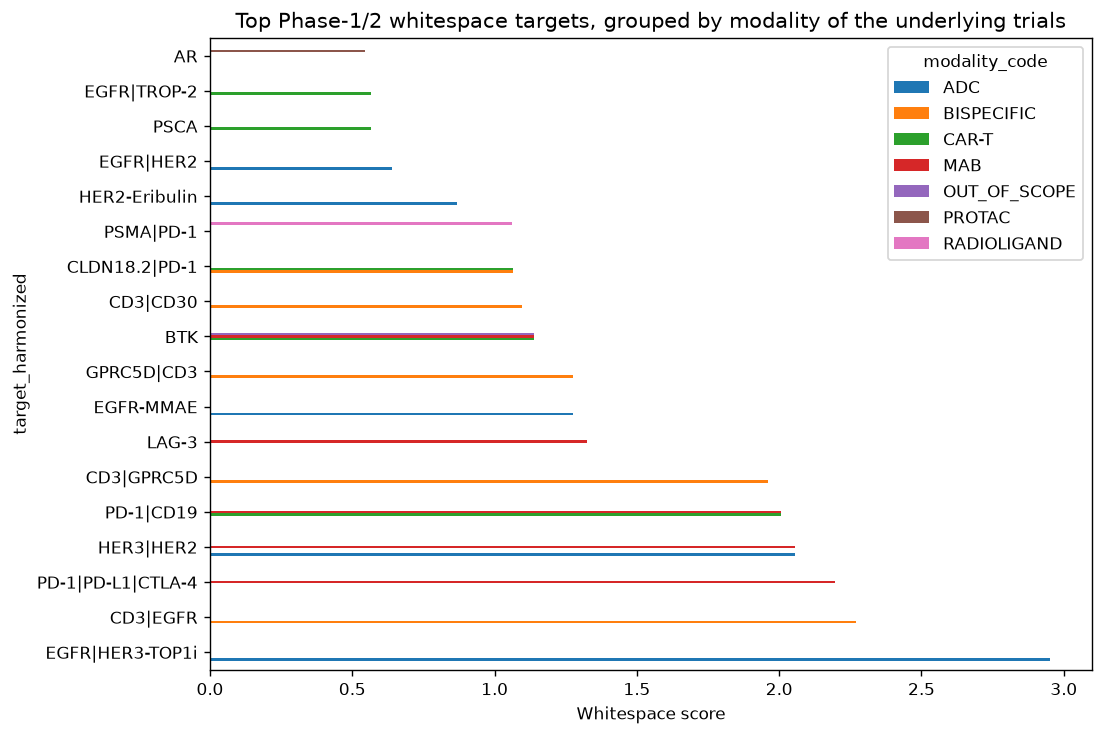

In [32]:
top_ws = WHITESPACE_OVERALL.head(40)
mod_map = df[df["target_h"].isin(top_ws["target_harmonized"])].groupby(["target_h", "modality_code"]).size().reset_index(name="n_trials")
merged = mod_map.merge(top_ws[["target_harmonized", "whitespace_score"]], left_on="target_h", right_on="target_harmonized")
by_modality = (merged.sort_values(["modality_code", "whitespace_score"], ascending=[True, False])
                      .groupby("modality_code").head(5)[["modality_code", "target_h", "n_trials", "whitespace_score"]]
                      .rename(columns={"target_h": "target_harmonized"}))
display(by_modality, name="entry32_whitespace_by_modality")

fig, ax = plt.subplots(figsize=(9, 6))
piv = by_modality.pivot_table(index="target_harmonized", columns="modality_code", values="whitespace_score", fill_value=0)
piv = piv.loc[by_modality.sort_values("whitespace_score", ascending=False)["target_harmonized"].unique()]
piv.plot(kind="barh", ax=ax, color=plt.cm.tab10.colors[:piv.shape[1]])
ax.set_xlabel("Whitespace score"); ax.set_title("Top Phase-1/2 whitespace targets, grouped by modality of the underlying trials")
plt.tight_layout()

## Entry 33: Whitespace Targets by Solid Tumor Type (Phase 1/2 Only)

,tumor_type,target_harmonized,n_trials,whitespace_score
0,Adrenal,B7-H3|WT1,1,-0.258479
18,Biliary_Cholangio,IL1RAP,1,1.051509
10,Biliary_Cholangio,CTLA-4|HER2|PD-1|PD-L1,2,0.896385
9,Biliary_Cholangio,CLDN18.2|CTLA-4|PD-1|PD-L1,1,0.752509
28,Biliary_Cholangio,PD-L1|FGFR,2,0.404673
30,Biliary_Cholangio,TROP-2|VEGF,1,0.404673
34,Bladder_Urothelial,BTK,1,1.136860
47,Bladder_Urothelial,IL1RAP,1,1.051509
40,Bladder_Urothelial,CTLA-4|HER2|PD-1|PD-L1,1,0.896385
35,Bladder_Urothelial,CCR8,1,0.565816


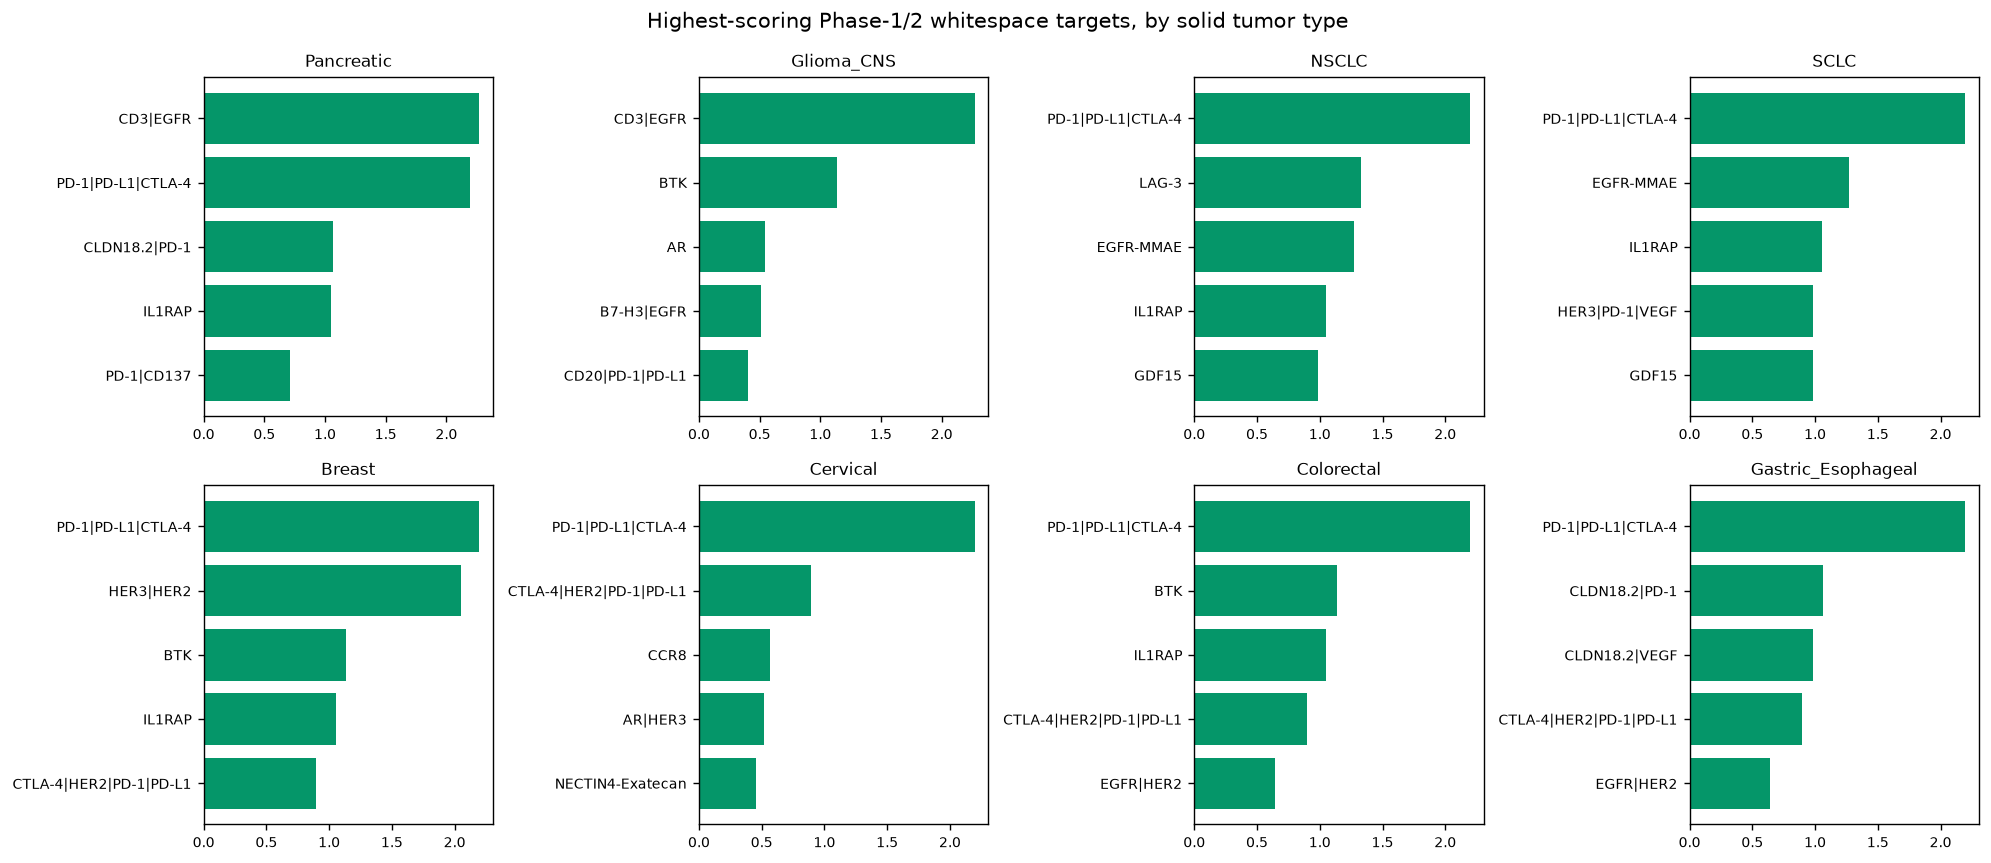

In [33]:
ws_targets = WHITESPACE_OVERALL["target_harmonized"].tolist()
ws_junction = tumor_junction[
    tumor_junction["target_h"].isin(ws_targets) &
    ~tumor_junction["tumor_type"].str.startswith("Hematologic") &
    (tumor_junction["tumor_type"] != "Solid_Tumor_Basket")
]
q = ws_junction.groupby(["tumor_type", "target_h"]).size().reset_index(name="n_trials")
q = q.merge(WHITESPACE_OVERALL[["target_harmonized", "whitespace_score"]], left_on="target_h", right_on="target_harmonized")
q = q.sort_values(["tumor_type", "whitespace_score"], ascending=[True, False]).groupby("tumor_type").head(5)
q = q[["tumor_type", "target_h", "n_trials", "whitespace_score"]].rename(columns={"target_h": "target_harmonized"})
display(q, name="entry33_whitespace_by_tumor_type")

top_tumors = (q.groupby("tumor_type")["whitespace_score"].max().sort_values(ascending=False).head(8).index.tolist())
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, tt in zip(axes.flat, top_tumors):
    sub = q[q["tumor_type"] == tt].sort_values("whitespace_score")
    ax.barh(sub["target_harmonized"], sub["whitespace_score"], color="#059669")
    ax.set_title(tt, fontsize=10)
    ax.tick_params(labelsize=8)
plt.suptitle("Highest-scoring Phase-1/2 whitespace targets, by solid tumor type")
plt.tight_layout()

## Entry 34: Novel/Emerging Candidate Spotlight -- Phase 1/2 Targets with Real Potential

In [34]:
# Deep-dive spotlight: single-or-few sponsor(s), recent (2022+), no
# failures, with at least one hint of early success OR strong momentum --
# the most interesting NOVEL candidates for our own program to consider.
spotlight = WHITESPACE_OVERALL[
    (WHITESPACE_OVERALL["earliest_start_year"] >= 2020) &
    (WHITESPACE_OVERALL["n_sponsors"] <= 3)
].copy()
spotlight = spotlight.merge(
    MOMENTUM_TABLE[["target_harmonized", "momentum_label", "momentum_ratio"]],
    on="target_harmonized", how="left")

ws_junction = tumor_junction[
    tumor_junction["target_h"].isin(spotlight["target_harmonized"]) &
    ~tumor_junction["tumor_type"].str.startswith("Hematologic") &
    (tumor_junction["tumor_type"] != "Solid_Tumor_Basket")
]
best_tumor = (ws_junction.groupby(["target_h", "tumor_type"]).size().reset_index(name="n")
                         .sort_values("n", ascending=False).drop_duplicates("target_h")
                         .rename(columns={"target_h": "target_harmonized", "tumor_type": "lead_tumor_type"}))
mod_counts = (df[df["target_h"].isin(spotlight["target_harmonized"])].groupby(["target_h", "modality_code"]).size()
                .reset_index(name="n").sort_values("n", ascending=False).drop_duplicates("target_h")
                .rename(columns={"target_h": "target_harmonized", "modality_code": "lead_modality"}))

spotlight = spotlight.merge(best_tumor[["target_harmonized", "lead_tumor_type"]], on="target_harmonized", how="left")
spotlight = spotlight.merge(mod_counts[["target_harmonized", "lead_modality"]], on="target_harmonized", how="left")
spotlight = spotlight.sort_values("whitespace_score", ascending=False)

cols = ["target_harmonized", "n_trials", "n_sponsors", "earliest_start_year", "latest_start_year",
        "n_success", "lead_tumor_type", "lead_modality", "momentum_label", "whitespace_score"]
SPOTLIGHT = spotlight[cols]
display(SPOTLIGHT.head(25), name="entry34_novel_candidate_spotlight")
print(f"{len(SPOTLIGHT)} novel Phase-1/2 candidates: recent first-in-human since 2020, "
      f"<=3 sponsors (low crowding), zero recorded failures.")

584 novel Phase-1/2 candidates: recent first-in-human since 2020, <=3 sponsors (low crowding), zero recorded failures.


,target_harmonized,n_trials,n_sponsors,earliest_start_year,latest_start_year,n_success,lead_tumor_type,lead_modality,momentum_label,whitespace_score
0,EGFR|HER3-TOP1i,6,1,2026.0,2026.0,2.0,-,ADC,-,2.950592
1,CD3|CD30,1,1,2026.0,2026.0,1.0,-,BISPECIFIC,-,1.098046
2,CLDN18.2|PD-1,3,3,2020.0,2024.0,1.0,Gastric_Esophageal,MAB,-,1.065488
4,HER3|PD-1|VEGF,1,1,2025.0,2025.0,1.0,SCLC,BISPECIFIC,-,0.982867
5,CLDN18.2|VEGF,1,1,2025.0,2025.0,1.0,Gastric_Esophageal,MAB,-,0.982867
3,GDF15,1,1,2025.0,2025.0,1.0,Lung_Other,MAB,-,0.982867
6,HER2-Eribulin,1,1,2024.0,2024.0,1.0,Breast,ADC,-,0.867688
7,CLDN18.2|CTLA-4|PD-1|PD-L1,1,1,2023.0,2023.0,1.0,Biliary_Cholangio,BISPECIFIC,-,0.752509
8,PD-1|VEGF|PD-L1|CTLA-4,4,1,2024.0,2024.0,0.0,Lung_Other,MAB,-,0.671652
9,CD19|CD3|CD20|BCL-2,1,1,2022.0,2022.0,1.0,-,BISPECIFIC,-,0.637330


## Entry 35: Portfolio Recommendation Shortlist -- Candidate Target/Modality/Tumor-Type Bets

In [35]:
ws_junction = tumor_junction[
    tumor_junction["target_h"].isin(WHITESPACE_OVERALL["target_harmonized"]) &
    ~tumor_junction["tumor_type"].str.startswith("Hematologic") &
    (tumor_junction["tumor_type"] != "Solid_Tumor_Basket")
]
tt_counts = ws_junction.groupby(["target_h", "tumor_type"]).size().reset_index(name="n_trials_in_tumor")
best_tumor = tt_counts.sort_values("n_trials_in_tumor", ascending=False).drop_duplicates("target_h")

mod_counts = df[df["target_h"].isin(WHITESPACE_OVERALL["target_harmonized"])].groupby(["target_h", "modality_code"]).size().reset_index(name="n_trials_in_modality")
best_modality = mod_counts.sort_values("n_trials_in_modality", ascending=False).drop_duplicates("target_h")

shortlist = WHITESPACE_OVERALL.head(15).copy()
shortlist = shortlist.merge(best_tumor.rename(columns={"target_h": "target_harmonized"}), on="target_harmonized", how="left")
shortlist = shortlist.merge(best_modality.rename(columns={"target_h": "target_harmonized"}), on="target_harmonized", how="left")
shortlist = shortlist.merge(MOMENTUM_TABLE[["target_harmonized", "momentum_label"]], on="target_harmonized", how="left")

def rationale(row):
    bits = [f"{row['n_trials']} trials since {int(row['earliest_start_year'])}", f"{row['n_sponsors']} sponsor(s) (low crowding)"]
    if row["n_success"] > 0:
        bits.append(f"{int(row['n_success'])} early positive readout(s)")
    else:
        bits.append("no failures recorded yet")
    if pd.notna(row.get("tumor_type")):
        bits.append(f"concentrated in {row['tumor_type']}")
    if pd.notna(row.get("modality_code")):
        bits.append(f"lead modality tested: {row['modality_code']}")
    if pd.notna(row.get("momentum_label")):
        bits.append(f"momentum: {row['momentum_label']}")
    return "; ".join(bits)

shortlist["rationale"] = shortlist.apply(rationale, axis=1)
cols = ["target_harmonized", "n_trials", "n_sponsors", "tumor_type", "modality_code", "whitespace_score", "rationale"]
display(shortlist[cols], name="entry35_portfolio_shortlist")

,target_harmonized,n_trials,n_sponsors,tumor_type,modality_code,whitespace_score,rationale
0,EGFR|HER3-TOP1i,6,1,-,ADC,2.950592,6 trials since 2026; 1 sponsor(s) (low crowding); 2 early positive readout(s); lead modality tested: ADC
1,CD3|EGFR,5,3,Pancreatic,BISPECIFIC,2.270951,5 trials since 2015; 3 sponsor(s) (low crowding); 2 early positive readout(s); concentrated in Pancreatic; lead modality tested: BISPECIFIC; momentum: Steady
2,PD-1|PD-L1|CTLA-4,4,4,Lung_Other,MAB,2.196291,4 trials since 2021; 4 sponsor(s) (low crowding); 2 early positive readout(s); concentrated in Lung_Other; lead modality tested: MAB
3,HER3|HER2,5,5,Breast,MAB,2.054572,5 trials since 2014; 5 sponsor(s) (low crowding); 2 early positive readout(s); concentrated in Breast; lead modality tested: MAB
4,PD-1|CD19,6,6,Hepatocellular,MAB,2.006518,6 trials since 2019; 6 sponsor(s) (low crowding); 2 early positive readout(s); concentrated in Hepatocellular; lead modality tested: MAB; momentum: Steady
5,CD3|GPRC5D,3,3,-,BISPECIFIC,1.961297,3 trials since 2017; 3 sponsor(s) (low crowding); 2 early positive readout(s); lead modality tested: BISPECIFIC
6,LAG-3,5,4,NSCLC,MAB,1.324542,5 trials since 2020; 4 sponsor(s) (low crowding); 1 early positive readout(s); concentrated in NSCLC; lead modality tested: MAB
7,GPRC5D|CD3,5,5,-,BISPECIFIC,1.273943,5 trials since 2021; 5 sponsor(s) (low crowding); 1 early positive readout(s); lead modality tested: BISPECIFIC
8,EGFR-MMAE,5,5,NSCLC,ADC,1.273943,5 trials since 2020; 5 sponsor(s) (low crowding); 1 early positive readout(s); concentrated in NSCLC; lead modality tested: ADC
9,BTK,8,7,Glioma_CNS,MAB,1.136860,8 trials since 2011; 7 sponsor(s) (low crowding); 1 early positive readout(s); concentrated in Glioma_CNS; lead modality tested: MAB; momentum: Steady


## Entry 36: Executive Summary & Key Findings

In [36]:
top_modality = con.sql("SELECT modality_code, COUNT(*) n FROM trials GROUP BY 1 ORDER BY 2 DESC LIMIT 1").df().iloc[0]
top_target_row = TARGET_SCORECARD.sort_values("n_trials", ascending=False).iloc[0]
n_validated = (TARGET_SCORECARD["target_status"] == "Validated (success recorded)").sum()
n_mixed = (TARGET_SCORECARD["target_status"] == "Mixed (succeeded & failed)").sum()
n_failed_only = (TARGET_SCORECARD["target_status"] == "Failed only (no success yet)").sum()
n_still_trial = (TARGET_SCORECARD["target_status"] == "Still-in-trial (no readout yet)").sum()
n_regimen_flagged = (REGIMEN_DIVERGENCE_MATCHED["divergence_flag"] != "No clear divergence").sum()
n_modality_flagged = (MODALITY_DIVERGENCE_MATCHED["divergence_flag"] != "No clear divergence").sum()
n_whitespace = len(WHITESPACE_OVERALL)
top_ws_target = WHITESPACE_OVERALL.iloc[0]["target_harmonized"]
n_spotlight = len(SPOTLIGHT)
n_heating = (MOMENTUM_TABLE["momentum_label"].isin(["Heating up (accelerating)", "New wave (no prior activity, now active)"])).sum()

print("EXECUTIVE SUMMARY -- Antibody Oncology Clinical Landscape (V2, Deep-Dive)")
print("=" * 74)
print(f"Universe analyzed: {len(df):,} in-scope antibody-modality oncology trial records "
      f"({df['nct'].nunique():,} unique NCT numbers).")
print(f"Dominant modality: {top_modality['modality_code']} ({int(top_modality['n']):,} trials).")
print(f"Most clinically active target: {top_target_row['target_harmonized']} "
      f"({int(top_target_row['n_trials'])} trials, {top_target_row['success_rate_%']:.1f}% success rate).")
print()
print(f"Among {len(TARGET_SCORECARD)} targets with >=5 trials:")
print(f"  - {n_validated} are VALIDATED (>=1 recorded clinical success/approval)")
print(f"  - {n_mixed} are MIXED (succeeded in some settings, failed in others)")
print(f"  - {n_failed_only} have FAILED ONLY so far (no success recorded)")
print(f"  - {n_still_trial} are STILL IN TRIAL with no readout yet")
print()
print(f"{n_regimen_flagged} target x tumor-type pairs show a population-matched IO-combo vs "
      f"all-comers outcome divergence.")
print(f"{n_modality_flagged} target x tumor-type pairs show a population-matched naked-mAb vs "
      f"ADC outcome divergence.")
print(f"{n_heating} targets are 'heating up' (accelerating recent activity or a brand-new wave).")
print()
print(f"{n_whitespace} targets qualify as Phase-1/2-only clinical WHITESPACE (zero recorded "
      f"failures, active since 2019). Top-ranked: {top_ws_target}.")
print(f"{n_spotlight} pass the tighter NOVEL-CANDIDATE spotlight filter (first-in-human since "
      f"2020, <=3 sponsors).")

EXECUTIVE SUMMARY -- Antibody Oncology Clinical Landscape (V2, Deep-Dive)
Universe analyzed: 16,648 in-scope antibody-modality oncology trial records (15,851 unique NCT numbers).
Dominant modality: MAB (12,446 trials).
Most clinically active target: PD-1 (2908 trials, 12.0% success rate).

Among 243 targets with >=5 trials:
  - 21 are VALIDATED (>=1 recorded clinical success/approval)
  - 99 are MIXED (succeeded in some settings, failed in others)
  - 83 have FAILED ONLY so far (no success recorded)
  - 40 are STILL IN TRIAL with no readout yet

8 target x tumor-type pairs show a population-matched IO-combo vs all-comers outcome divergence.
25 target x tumor-type pairs show a population-matched naked-mAb vs ADC outcome divergence.
47 targets are 'heating up' (accelerating recent activity or a brand-new wave).

686 targets qualify as Phase-1/2-only clinical WHITESPACE (zero recorded failures, active since 2019). Top-ranked: EGFR|HER3-TOP1i.
584 pass the tighter NOVEL-CANDIDATE spotlight

## Entry 37: Risk-Tier Classification Framework -- Low (Validated) / Medium (Hybrid) / High (Whitespace/Novel)

In [37]:
# LOW RISK -- validated biology: target already has >=1 recorded clinical
# success/approval (any modality). Fastest path, lowest differentiation.
low_risk = TARGET_SCORECARD[TARGET_SCORECARD["target_status"] == "Validated (success recorded)"].copy()
low_risk["risk_tier"] = "Low risk (validated biology)"
LOW_RISK = low_risk.sort_values("success_rate_%", ascending=False)

# HIGH RISK -- whitespace / novel: Phase-1/2-only footprint, zero
# recorded failures (already computed in Entry 31). Highest differentiation upside.
high_risk = WHITESPACE_OVERALL.copy()
high_risk["risk_tier"] = "High risk (whitespace / novel)"
HIGH_RISK = high_risk

# MEDIUM RISK -- hybrid: target IS validated in a primary modality, but a
# DIFFERENT modality remains underexplored (1-6 trials) with zero
# recorded failures there -- validated biology + a novel modality/payload
# angle. ADC is preferred first since the org has in-house ADC capability.
mod_stats = con.sql('''
    SELECT target_h AS target_harmonized, modality_code, COUNT(*) AS n_trials,
           SUM(CASE WHEN outcome_bucket='Success' THEN 1 ELSE 0 END) AS n_success,
           SUM(CASE WHEN outcome_bucket='Failure' THEN 1 ELSE 0 END) AS n_failure
    FROM trials WHERE target_h IS NOT NULL GROUP BY 1,2
''').df()
validated_targets = set(TARGET_SCORECARD[TARGET_SCORECARD["n_success"] > 0]["target_harmonized"])
mod_stats_v = mod_stats[mod_stats["target_harmonized"].isin(validated_targets)]

MODALITY_PREF = {"ADC": 0, "BISPECIFIC": 1, "BiTE": 2, "CAR-T": 3, "RADIOLIGAND": 4}
hybrid_rows = []
for target, g in mod_stats_v.groupby("target_harmonized"):
    succ_rows = g[g["n_success"] > 0]
    primary = succ_rows.loc[succ_rows["n_success"].idxmax()] if len(succ_rows) else g.loc[g["n_trials"].idxmax()]
    alt = g[(g["modality_code"] != primary["modality_code"]) & (g["n_trials"].between(1, 6)) & (g["n_failure"] == 0)].copy()
    if len(alt):
        alt["pref"] = alt["modality_code"].map(MODALITY_PREF).fillna(9)
        best_alt = alt.sort_values("pref").iloc[0]
        hybrid_rows.append({
            "target_harmonized": target,
            "validated_modality": primary["modality_code"],
            "validated_modality_trials": int(primary["n_trials"]),
            "validated_modality_success": int(primary["n_success"]),
            "novel_modality_angle": best_alt["modality_code"],
            "novel_modality_trials": int(best_alt["n_trials"]),
        })
MEDIUM_RISK = pd.DataFrame(hybrid_rows).sort_values("validated_modality_success", ascending=False)
MEDIUM_RISK["risk_tier"] = "Medium risk (hybrid: validated target, novel modality angle)"

display(LOW_RISK[["target_harmonized", "n_trials", "n_sponsors", "success_rate_%"]].head(20), name="entry37_low_risk_validated_targets")
display(MEDIUM_RISK.head(30), name="entry37_medium_risk_hybrid_targets")
display(HIGH_RISK[["target_harmonized", "n_trials", "n_sponsors", "whitespace_score"]].head(20), name="entry37_high_risk_whitespace_targets")

print(f"Low risk (validated biology): {len(LOW_RISK)} targets")
print(f"Medium risk (hybrid, validated target + novel modality angle -- ADC preferred): {len(MEDIUM_RISK)} targets")
print(f"High risk (whitespace / novel): {len(HIGH_RISK)} targets")

Low risk (validated biology): 21 targets
Medium risk (hybrid, validated target + novel modality angle -- ADC preferred): 46 targets
High risk (whitespace / novel): 686 targets


,target_harmonized,n_trials,n_sponsors,success_rate_%
83,TROP-2-Dxd,17,7,94.1
204,HER3|HER2,5,5,40.0
220,CD3|EGFR,5,3,40.0
95,TROP-2-KL610023,14,11,35.7
177,CD30-MMAE,6,5,33.3
108,Tissue factor,12,9,33.3
185,EGFR|HER3-TOP1i,6,1,33.3
188,PD-1|CD19,6,6,33.3
231,BCL-2|CD20,5,5,20.0
225,LAG-3,5,4,20.0


,target_harmonized,validated_modality,validated_modality_trials,validated_modality_success,novel_modality_angle,novel_modality_trials,risk_tier
40,VEGF,MAB,854,224,OUT_OF_SCOPE,1,"Medium risk (hybrid: validated target, novel modality angle)"
33,PD-L1,MAB,769,78,ADC,2,"Medium risk (hybrid: validated target, novel modality angle)"
19,HER2,MAB,904,47,PROTAC,1,"Medium risk (hybrid: validated target, novel modality angle)"
41,VEGFR2,MAB,52,24,BISPECIFIC,1,"Medium risk (hybrid: validated target, novel modality angle)"
31,PD-1|PD-L1,MAB,455,21,CAR-T,3,"Medium risk (hybrid: validated target, novel modality angle)"
13,EGFR,MAB,689,12,ANTISENSE,1,"Medium risk (hybrid: validated target, novel modality angle)"
32,PD-1|VEGF,BISPECIFIC,55,12,ADC,2,"Medium risk (hybrid: validated target, novel modality angle)"
11,CTLA-4|PD-1,MAB,274,11,CAR-T,2,"Medium risk (hybrid: validated target, novel modality angle)"
15,EGFR|MET,BISPECIFIC,40,8,MULTISPECIFIC,1,"Medium risk (hybrid: validated target, novel modality angle)"
4,CD19|CD3,BISPECIFIC,42,6,MAB,1,"Medium risk (hybrid: validated target, novel modality angle)"


,target_harmonized,n_trials,n_sponsors,whitespace_score
1532,EGFR|HER3-TOP1i,6,1,2.950592
1490,CD3|EGFR,5,3,2.270951
1188,PD-1|PD-L1|CTLA-4,4,4,2.196291
1089,HER3|HER2,5,5,2.054572
1442,PD-1|CD19,6,6,2.006518
21,CD3|GPRC5D,3,3,1.961297
1383,LAG-3,5,4,1.324542
840,GPRC5D|CD3,5,5,1.273943
899,EGFR-MMAE,5,5,1.273943
1109,BTK,8,7,1.136860


## Entry 38: Chart -- Risk-Tier Landscape (Counts & Crowding-vs-Validation Scatter)

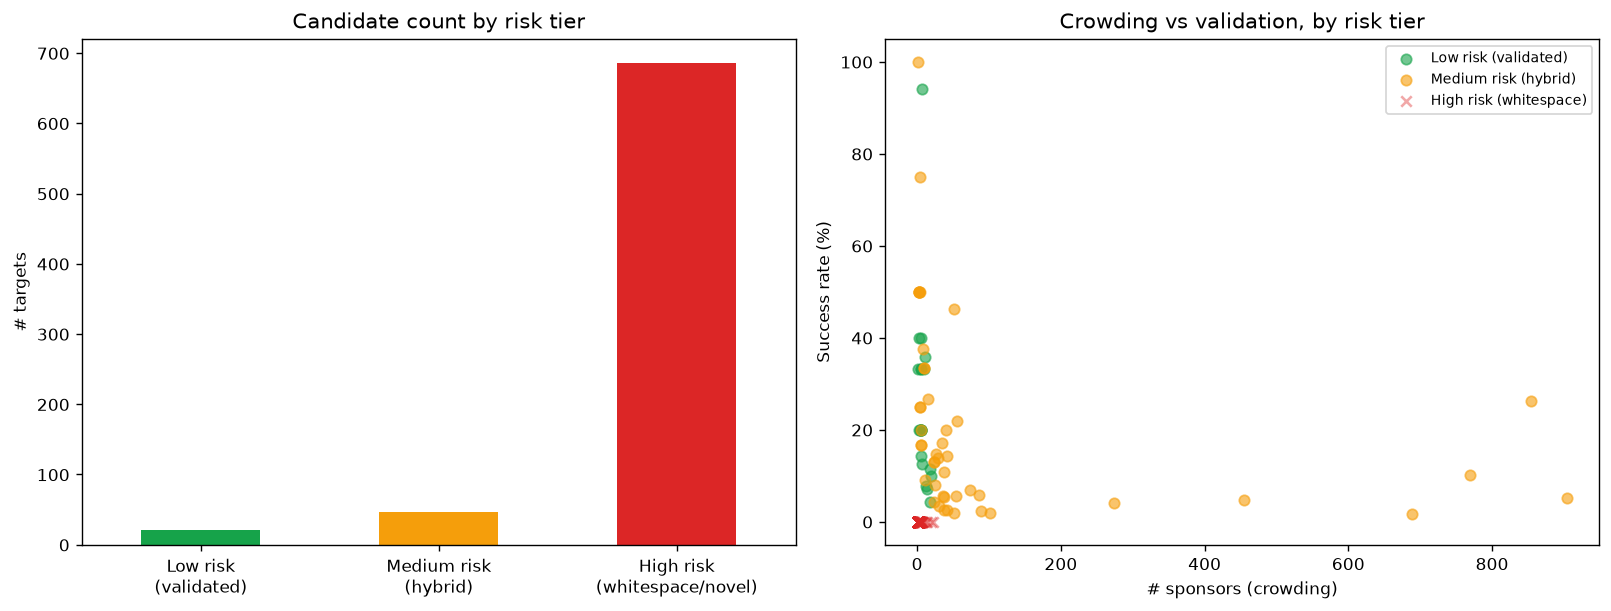

In [38]:
tier_counts = pd.Series({
    "Low risk\n(validated)": len(LOW_RISK),
    "Medium risk\n(hybrid)": len(MEDIUM_RISK),
    "High risk\n(whitespace/novel)": len(HIGH_RISK),
})
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
tier_counts.plot(kind="bar", ax=axes[0], color=["#16a34a", "#f59e0b", "#dc2626"])
axes[0].set_title("Candidate count by risk tier"); axes[0].set_ylabel("# targets")
axes[0].tick_params(axis="x", rotation=0)

axes[1].scatter(LOW_RISK["n_sponsors"], LOW_RISK["success_rate_%"], color="#16a34a", label="Low risk (validated)", alpha=0.6)
axes[1].scatter(MEDIUM_RISK["validated_modality_trials"], MEDIUM_RISK["validated_modality_success"] / MEDIUM_RISK["validated_modality_trials"] * 100,
                 color="#f59e0b", label="Medium risk (hybrid)", alpha=0.6)
axes[1].scatter(HIGH_RISK["n_sponsors"], np.zeros(len(HIGH_RISK)), color="#dc2626", label="High risk (whitespace)", alpha=0.4, marker="x")
axes[1].set_xlabel("# sponsors (crowding)"); axes[1].set_ylabel("Success rate (%)")
axes[1].set_title("Crowding vs validation, by risk tier")
axes[1].legend(fontsize=8)
plt.tight_layout()

## Entry 39: Tumor-AGNOSTIC Shortlist by Risk Tier (Ranked on Target/Modality Merit Alone)

In [39]:
# View #1 of the dual-view ask: ignore tumor type entirely, rank purely
# on target-level clinical/competitive merit within each risk tier.
rows = []
for _, r in LOW_RISK.head(8).iterrows():
    rows.append({"risk_tier": "Low risk (validated)", "target_harmonized": r["target_harmonized"],
                 "key_metric": f"{r['success_rate_%']:.1f}% success rate ({int(r['n_trials'])} trials, {int(r['n_sponsors'])} sponsors)"})
for _, r in MEDIUM_RISK.head(8).iterrows():
    rows.append({"risk_tier": "Medium risk (hybrid)", "target_harmonized": r["target_harmonized"],
                 "key_metric": f"validated as {r['validated_modality']} ({int(r['validated_modality_success'])} success); "
                                f"{r['novel_modality_angle']} angle barely tested ({int(r['novel_modality_trials'])} trials, 0 failures)"})
for _, r in HIGH_RISK.head(8).iterrows():
    rows.append({"risk_tier": "High risk (whitespace/novel)", "target_harmonized": r["target_harmonized"],
                 "key_metric": f"whitespace score {r['whitespace_score']:.2f} ({int(r['n_trials'])} trials, {int(r['n_sponsors'])} sponsors)"})
TUMOR_AGNOSTIC_SHORTLIST = pd.DataFrame(rows)
display(TUMOR_AGNOSTIC_SHORTLIST, name="entry39_tumor_agnostic_shortlist")

,risk_tier,target_harmonized,key_metric
0,Low risk (validated),TROP-2-Dxd,"94.1% success rate (17 trials, 7 sponsors)"
1,Low risk (validated),HER3|HER2,"40.0% success rate (5 trials, 5 sponsors)"
2,Low risk (validated),CD3|EGFR,"40.0% success rate (5 trials, 3 sponsors)"
3,Low risk (validated),TROP-2-KL610023,"35.7% success rate (14 trials, 11 sponsors)"
4,Low risk (validated),CD30-MMAE,"33.3% success rate (6 trials, 5 sponsors)"
5,Low risk (validated),Tissue factor,"33.3% success rate (12 trials, 9 sponsors)"
6,Low risk (validated),EGFR|HER3-TOP1i,"33.3% success rate (6 trials, 1 sponsors)"
7,Low risk (validated),PD-1|CD19,"33.3% success rate (6 trials, 6 sponsors)"
8,Medium risk (hybrid),VEGF,"validated as MAB (224 success); OUT_OF_SCOPE angle barely tested (1 trials, 0 failures)"
9,Medium risk (hybrid),PD-L1,"validated as MAB (78 success); ADC angle barely tested (2 trials, 0 failures)"


## Entry 40: Tumor-ANCHORED Shortlist by Risk Tier (Best Targets Within Each Top Solid Tumor Type)

In [40]:
# View #2 of the dual-view ask: for each of the 8 most-studied solid
# tumor types, the best target in each risk tier that has real activity
# in that specific tumor type.
top_tumors = (tumor_junction[~tumor_junction["tumor_type"].str.startswith("Hematologic") &
                             (tumor_junction["tumor_type"] != "Solid_Tumor_Basket")]
              ["tumor_type"].value_counts().head(8).index.tolist())

tier_targets = {
    "Low risk (validated)": set(LOW_RISK["target_harmonized"]),
    "Medium risk (hybrid)": set(MEDIUM_RISK["target_harmonized"]),
    "High risk (whitespace/novel)": set(HIGH_RISK["target_harmonized"]),
}
rows = []
for tt in top_tumors:
    tt_counts = tumor_junction[tumor_junction["tumor_type"] == tt].groupby("target_h").size()
    for tier_name, targets in tier_targets.items():
        candidates = tt_counts[tt_counts.index.isin(targets)].sort_values(ascending=False)
        if len(candidates):
            best_target = candidates.index[0]
            rows.append({"tumor_type": tt, "risk_tier": tier_name, "target_harmonized": best_target,
                         "n_trials_in_tumor_type": int(candidates.iloc[0])})
TUMOR_ANCHORED_SHORTLIST = pd.DataFrame(rows)
display(TUMOR_ANCHORED_SHORTLIST, name="entry40_tumor_anchored_shortlist")
print(f"Covers {len(top_tumors)} tumor types x up to 3 risk tiers = {len(TUMOR_ANCHORED_SHORTLIST)} tumor-anchored recommendations.")

Covers 8 tumor types x up to 3 risk tiers = 24 tumor-anchored recommendations.


,tumor_type,risk_tier,target_harmonized,n_trials_in_tumor_type
0,Lung_Other,Low risk (validated),DLL3|CD3,25
1,Lung_Other,Medium risk (hybrid),PD-L1,277
2,Lung_Other,High risk (whitespace/novel),PD-1|PD-L1|CTLA-4,4
3,NSCLC,Low risk (validated),TROP-2-Dxd,15
4,NSCLC,Medium risk (hybrid),PD-L1,195
5,NSCLC,High risk (whitespace/novel),HER2|PD-L1-TOP1i,3
6,Breast,Low risk (validated),HER2|TROP-2,11
7,Breast,Medium risk (hybrid),HER2,884
8,Breast,High risk (whitespace/novel),HER2|TROP-2,11
9,SCLC,Low risk (validated),DLL3|CD3,19


## Entry 41: Combo-Strategy Feasibility Tagging -- Why Regimen Choice Matters per Candidate

In [41]:
# WHY THIS MATTERS: Entries 19/23 showed outcomes for the SAME target can
# flip entirely depending on regimen (e.g. a target only ever succeeds as
# an IO-combo, and fails/is untested as monotherapy). If our org cannot
# access an IO backbone (in-house or via partnership), any candidate
# whose only recorded success is IO-combo is NOT actually accessible to
# us -- it would need to be de-prioritized or paired with a combo deal.
# This entry tags every shortlisted candidate with its regimen feasibility
# so the choice can be made per-target rather than as a blanket policy.
def combo_feasibility(target, tumor_type=None):
    if tumor_type is not None:
        row = REGIMEN_DIVERGENCE_MATCHED[(REGIMEN_DIVERGENCE_MATCHED["target_harmonized"] == target) &
                                         (REGIMEN_DIVERGENCE_MATCHED["tumor_type"] == tumor_type)]
        if len(row):
            r = row.iloc[0]
            if r["n_success_mono"] > 0:
                return "Monotherapy validated (this tumor type)"
            if r["n_success_IO_combo"] > 0 and r["n_success_mono"] == 0:
                return "Requires IO-combo access (this tumor type)"
    sub = PARTNER_CLASS_TABLE[PARTNER_CLASS_TABLE["target_harmonized"] == target]
    if len(sub):
        def has_success(bucket):
            r = sub[sub["partner_class_bucket"] == bucket]
            return len(r) > 0 and r.iloc[0]["n_success"] > 0
        if has_success("Monotherapy"):
            return "Monotherapy validated (any tumor type)"
        if has_success("IO-combo"):
            return "Requires IO-combo access"
        if has_success("Chemo-combo"):
            return "Requires chemo-combo access"
        if has_success("TKI-combo"):
            return "Requires TKI-combo access"
    return "Regimen data insufficient / untested"

agnostic = TUMOR_AGNOSTIC_SHORTLIST.copy()
agnostic["combo_feasibility"] = agnostic["target_harmonized"].apply(lambda t: combo_feasibility(t))

anchored = TUMOR_ANCHORED_SHORTLIST.copy()
anchored["combo_feasibility"] = anchored.apply(lambda r: combo_feasibility(r["target_harmonized"], r["tumor_type"]), axis=1)

COMBO_FEASIBILITY_AGNOSTIC = agnostic
COMBO_FEASIBILITY_ANCHORED = anchored
display(agnostic, name="entry41_combo_feasibility_tumor_agnostic")
display(anchored, name="entry41_combo_feasibility_tumor_anchored")

print("Combo-feasibility mix, tumor-agnostic shortlist:")
print(agnostic["combo_feasibility"].value_counts().to_string())
print("\nCombo-feasibility mix, tumor-anchored shortlist:")
print(anchored["combo_feasibility"].value_counts().to_string())

Combo-feasibility mix, tumor-agnostic shortlist:
combo_feasibility
Monotherapy validated (any tumor type)    24

Combo-feasibility mix, tumor-anchored shortlist:
combo_feasibility
Monotherapy validated (any tumor type)     15
Regimen data insufficient / untested        5
Monotherapy validated (this tumor type)     4


,risk_tier,target_harmonized,key_metric,combo_feasibility
0,Low risk (validated),TROP-2-Dxd,"94.1% success rate (17 trials, 7 sponsors)",Monotherapy validated (any tumor type)
1,Low risk (validated),HER3|HER2,"40.0% success rate (5 trials, 5 sponsors)",Monotherapy validated (any tumor type)
2,Low risk (validated),CD3|EGFR,"40.0% success rate (5 trials, 3 sponsors)",Monotherapy validated (any tumor type)
3,Low risk (validated),TROP-2-KL610023,"35.7% success rate (14 trials, 11 sponsors)",Monotherapy validated (any tumor type)
4,Low risk (validated),CD30-MMAE,"33.3% success rate (6 trials, 5 sponsors)",Monotherapy validated (any tumor type)
5,Low risk (validated),Tissue factor,"33.3% success rate (12 trials, 9 sponsors)",Monotherapy validated (any tumor type)
6,Low risk (validated),EGFR|HER3-TOP1i,"33.3% success rate (6 trials, 1 sponsors)",Monotherapy validated (any tumor type)
7,Low risk (validated),PD-1|CD19,"33.3% success rate (6 trials, 6 sponsors)",Monotherapy validated (any tumor type)
8,Medium risk (hybrid),VEGF,"validated as MAB (224 success); OUT_OF_SCOPE angle barely tested (1 trials, 0 failures)",Monotherapy validated (any tumor type)
9,Medium risk (hybrid),PD-L1,"validated as MAB (78 success); ADC angle barely tested (2 trials, 0 failures)",Monotherapy validated (any tumor type)


,tumor_type,risk_tier,target_harmonized,n_trials_in_tumor_type,combo_feasibility
0,Lung_Other,Low risk (validated),DLL3|CD3,25,Monotherapy validated (any tumor type)
1,Lung_Other,Medium risk (hybrid),PD-L1,277,Monotherapy validated (this tumor type)
2,Lung_Other,High risk (whitespace/novel),PD-1|PD-L1|CTLA-4,4,Monotherapy validated (any tumor type)
3,NSCLC,Low risk (validated),TROP-2-Dxd,15,Monotherapy validated (this tumor type)
4,NSCLC,Medium risk (hybrid),PD-L1,195,Monotherapy validated (this tumor type)
5,NSCLC,High risk (whitespace/novel),HER2|PD-L1-TOP1i,3,Regimen data insufficient / untested
6,Breast,Low risk (validated),HER2|TROP-2,11,Monotherapy validated (any tumor type)
7,Breast,Medium risk (hybrid),HER2,884,Monotherapy validated (any tumor type)
8,Breast,High risk (whitespace/novel),HER2|TROP-2,11,Monotherapy validated (any tumor type)
9,SCLC,Low risk (validated),DLL3|CD3,19,Monotherapy validated (any tumor type)


## Entry 42: Chart -- Combo-Strategy Feasibility Mix Across Shortlisted Candidates

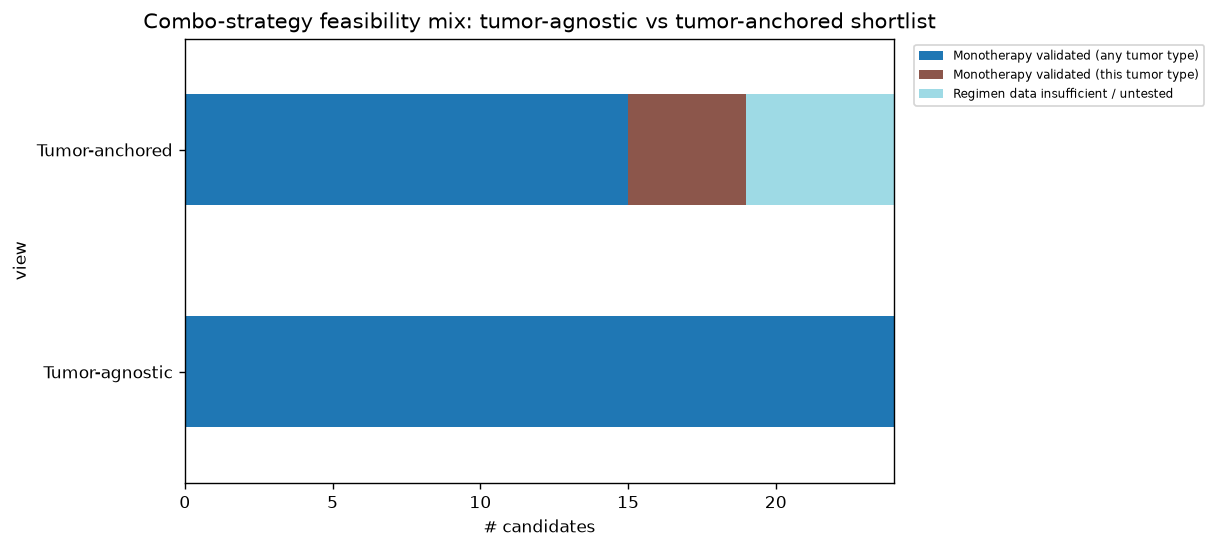

In [42]:
combined = pd.concat([
    COMBO_FEASIBILITY_AGNOSTIC[["combo_feasibility"]].assign(view="Tumor-agnostic"),
    COMBO_FEASIBILITY_ANCHORED[["combo_feasibility"]].assign(view="Tumor-anchored"),
])
pivot = combined.groupby(["view", "combo_feasibility"]).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(10, 4.5))
pivot.plot(kind="barh", stacked=True, ax=ax, colormap="tab20")
ax.set_xlabel("# candidates"); ax.set_title("Combo-strategy feasibility mix: tumor-agnostic vs tumor-anchored shortlist")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
plt.tight_layout()

## Entry 43: Final Consolidated Recommendation Matrix & Updated Executive Summary (V2.1, Post-Interview)

In [43]:
print("CONSOLIDATED RECOMMENDATION MATRIX")
print("=" * 74)
print("Dual view (per interview: both tumor-agnostic AND tumor-anchored, not either/or):\n")
print("-- TUMOR-AGNOSTIC (target/modality merit only) --")
print(COMBO_FEASIBILITY_AGNOSTIC.to_string(index=False))
print("\n-- TUMOR-ANCHORED (best target per risk tier, per top solid tumor type) --")
print(COMBO_FEASIBILITY_ANCHORED.to_string(index=False))

n_mono_ready = int((COMBO_FEASIBILITY_AGNOSTIC["combo_feasibility"].str.startswith("Monotherapy")).sum() +
                    (COMBO_FEASIBILITY_ANCHORED["combo_feasibility"].str.startswith("Monotherapy")).sum())
n_io_needed = int((COMBO_FEASIBILITY_AGNOSTIC["combo_feasibility"].str.contains("IO-combo")).sum() +
                   (COMBO_FEASIBILITY_ANCHORED["combo_feasibility"].str.contains("IO-combo")).sum())

print()
print("EXECUTIVE SUMMARY V2.1 -- POST-INTERVIEW (risk-tiered, dual tumor view, combo-tagged)")
print("=" * 74)
print(f"Per your interview answers: (1) in-house ADC capability confirmed -> Medium-risk hybrid "
      f"tier prioritizes ADC as the novel-modality angle for validated targets; (2) tiered risk "
      f"model adopted -- {len(LOW_RISK)} low-risk / {len(MEDIUM_RISK)} medium-risk / {len(HIGH_RISK)} "
      f"high-risk candidates identified; (3) BOTH tumor-agnostic ({len(COMBO_FEASIBILITY_AGNOSTIC)} "
      f"candidates) and tumor-anchored ({len(COMBO_FEASIBILITY_ANCHORED)} candidates across "
      f"{COMBO_FEASIBILITY_ANCHORED['tumor_type'].nunique()} tumor types) shortlists are produced; "
      f"(4) combo strategy tagged per-candidate rather than assumed -- {n_mono_ready} candidates "
      f"across both views are monotherapy-ready today, {n_io_needed} would need IO-combo access "
      f"(in-house or partnered) to realize their only recorded success signal.")
print()
print("Recommended next step: pressure-test the Medium-risk hybrid tier first (validated biology "
      "de-risks target selection, ADC capability is already in-house so no new platform "
      "investment is required) while running 1-2 High-risk whitespace bets in parallel for "
      "differentiation upside, prioritizing monotherapy-ready candidates unless an IO-combo "
      "partnership is already in place.")

CONSOLIDATED RECOMMENDATION MATRIX
Dual view (per interview: both tumor-agnostic AND tumor-anchored, not either/or):

-- TUMOR-AGNOSTIC (target/modality merit only) --
                   risk_tier target_harmonized                                                                              key_metric                      combo_feasibility
        Low risk (validated)        TROP-2-Dxd                                              94.1% success rate (17 trials, 7 sponsors) Monotherapy validated (any tumor type)
        Low risk (validated)         HER3|HER2                                               40.0% success rate (5 trials, 5 sponsors) Monotherapy validated (any tumor type)
        Low risk (validated)          CD3|EGFR                                               40.0% success rate (5 trials, 3 sponsors) Monotherapy validated (any tumor type)
        Low risk (validated)   TROP-2-KL610023                                             35.7% success rate (14 trials, 11 sponsors) M